# Spike Analysis

This notebook contains the entire empirical analysis on the three spike homologs as seen in our manuscript _Jointly modeling deep mutational scans identifies shifted mutational effects among SARS-CoV-2 spike homologs_.

## Computational platform environment

This section shows the attributes of the machine which ran this notebook, as well as imports the necessary dependencies.

Operating system

In [28]:
! grep -E '^(VERSION|NAME)=' /etc/os-release

NAME="Ubuntu"
VERSION="18.04.6 LTS (Bionic Beaver)"


/home/jgallowa/mambaforge/envs/multidms-dev/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Hardware (Processors and RAM)

In [29]:
! lshw -class memory -class processor

  *-memory                  
       description: System memory
       physical id: 0
       size: 996GiB
  *-cpu
       product: AMD EPYC 75F3 32-Core Processor
       vendor: Advanced Micro Devices [AMD]
       physical id: 1
       bus info: cpu@0
       size: 3027MHz
       width: 64 bits
       capabilities: fpu fpu_exception wp vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp x86-64 constant_tsc rep_good nopl xtopology nonstop_tsc cpuid extd_apicid aperfmperf pni pclmulqdq monitor ssse3 fma cx16 pcid sse4_1 sse4_2 movbe popcnt aes xsave avx f16c rdrand lahf_lm cmp_legacy svm extapic cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw ibs skinit wdt tce topoext perfctr_core perfctr_nb bpext perfctr_llc mwaitx cpb cat_l3 cdp_l3 invpcid_single hw_pstate ssbd ibrs ibpb stibp vmmcall fsgsbase bmi1 avx2 smep bmi2 invpcid cqm rdt_a rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 xsave

GPU's

In [30]:
%env CUDA_VISIBLE_DEVICES=0
! nvidia-smi -L

env: CUDA_VISIBLE_DEVICES=0
GPU 0: NVIDIA A100 80GB PCIe (UUID: GPU-e54c2054-5be3-ebd0-e22e-b98441ec664f)
GPU 1: NVIDIA A100 80GB PCIe (UUID: GPU-414cb1bd-372a-4926-b140-b734687c927f)


## Notebook configuraion

In [31]:
# built-in libraries
import os
import sys
from itertools import combinations
from collections import defaultdict
import time
import pprint
import copy
import pickle
from functools import reduce

# external dependencies
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from matplotlib.transforms import (
    Bbox, TransformedBbox, blended_transform_factory)
from mpl_toolkits.axes_grid1.inset_locator import (
    BboxPatch, BboxConnector, BboxConnectorPatch)
import matplotlib.patches as patches
import matplotlib.colors as colors
import numpy as np
import scipy
# from tqdm.notebook import tqdm
import jax
import jax.numpy as jnp
import shutil
from Bio.PDB.PDBParser import PDBParser
from Bio.PDB.PDBList import PDBList
from Bio.PDB.DSSP import DSSP
from Bio import SeqIO
from polyclonal.utils import MutationParser
import multidms
%matplotlib inline

This was notebook was run with the following `multidms` version.

In [32]:
multidms.__version__

'0.4.0'

set papermill parameters which define notebook behavior

In [33]:
output_dir = 'results/test'

pseudocount = 0.5
pre_count_threshold = 100
post_count_threshold = 0
func_score_lower_clip = -3.5
func_score_upper_clip = 2.5

num_data_workers = 4 
num_fit_threads = 24

# FITTING PARAMS
check_cache = False
output_activation = "Identity"
scale_coeff_lasso_shift = [
    0.0, 
    5.00e-6, 
    1.00e-05, 
    2.00e-05, 
    4.00e-05, 
    8.00e-05, 
    1.60e-04, 
    3.20e-04, 
    6.40e-04
] # the sweep of lasso coefficient params
maxiter = 100000 # 50000
init_theta_scale = 6.0
init_theta_bias = -3.5
scale_coeff_ridge_beta = 1e-7 # the sweep of ridge coefficient params
scale_coeff_ridge_ge_scale = 0
maxiter_single_condition = 3000 # 3000
train_frac = 0.8 # fraction of data to use for cross validation training.
seed = 4 # just for train/test split
# the number of times a mutation must be seen in each condition to be included in downstream analysis
times_seen_threshold = 1
# The chosen lasso strength for our final spike model results
chosen_lasso_strength = 4e-5
# lasso_choice = 4.00e-05 # the lasso coefficient to use for the final model
down_sample = False # downsample for notebook testing and dev

Set some global configurations for plotting.

In [35]:
if not os.path.exists(output_dir): os.mkdir(output_dir)

rc_kwargs = {
    'legend.frameon': False,
    "font.size" : 11,
    "font.weight" : "normal"
}

plt.rcParams.update(**rc_kwargs)

## Prepare Functional Score Data
Load and organize the funcational score dms data.

We begin with 16 individual sets of barcoded variants and their associated functional scores pre-computed. Each set derives from a single DMS experiment using one of Delta, Omicron BA.1, or Omicron BA.2 as the experimental wildtype. First, we parse the filenames to get experimental attributes tied in with the individual datasets as nested pd.DataFrames

In [36]:
func_score_data = pd.DataFrame()

for homolog in ["Delta", "Omicron_BA1", "Omicron_BA2"]:
    
    # functional scores
    func_sel = (
        pd.read_csv(f"data/{homolog}/functional_selections.csv")
        .assign(
            filename = lambda x: f"data/{homolog}/" + 
            x.library + "_" + 
            x.preselection_sample + 
            "_vs_" + x.postselection_sample + 
            "_func_scores.csv"
        )
        .assign(
            func_sel_scores_df = lambda x: x.filename.apply(
                lambda f: pd.read_csv(f)
            )   
        )
        .assign(
            len_func_sel_scores_df = lambda x: x.func_sel_scores_df.apply(
                lambda x: len(x)
            )
        )
        .assign(homolog = homolog)
    )
    func_score_data = pd.concat([func_score_data, func_sel]).reset_index(drop=True)

# Add a column that gives a unique ID to each homolog/DMS experiment
func_score_data['condition'] = func_score_data.apply(
    lambda row: f"{row['homolog']}-{row['library']}".replace('-Lib',''),
    axis=1
)
func_score_data[['library', 'replicate', 'filename', 'condition']]

,library,replicate,filename,condition
0,Lib-1,1,data/Delta/Lib-1_2021-10-28_thaw-1_VSVG_contro...,Delta-1
1,Lib-1,2,data/Delta/Lib-1_2021-10-28_thaw-1_VSVG_contro...,Delta-1
2,Lib-3,1,data/Delta/Lib-3_2021-10-28_thaw-1_VSVG_contro...,Delta-3
3,Lib-3,2,data/Delta/Lib-3_2021-10-28_thaw-1_VSVG_contro...,Delta-3
4,Lib-4,1,data/Delta/Lib-4_2021-10-28_thaw-1_VSVG_contro...,Delta-4
5,Lib-4,2,data/Delta/Lib-4_2021-10-28_thaw-1_VSVG_contro...,Delta-4
6,Lib-2,1,data/Delta/Lib-2_2021-10-28_thaw-1_VSVG_contro...,Delta-2
7,Lib-2,2,data/Delta/Lib-2_2021-10-28_thaw-1_VSVG_contro...,Delta-2
8,Lib-1,1,data/Omicron_BA1/Lib-1_2022-03-25_thaw-1_VSVG_...,Omicron_BA1-1
9,Lib-1,2,data/Omicron_BA1/Lib-1_2022-03-25_thaw-1_VSVG_...,Omicron_BA1-1


In [37]:
avail_cond_str = '\n- '.join(list(func_score_data.condition.unique()))
print(f"Available conditions for fitting are:\n- {avail_cond_str}")

Available conditions for fitting are:
- Delta-1
- Delta-3
- Delta-4
- Delta-2
- Omicron_BA1-1
- Omicron_BA1-2
- Omicron_BA1-3
- Omicron_BA2-1
- Omicron_BA2-2


Concatentate each of the individual experiments, keeping track of the library and homolog of each. Output noteable features, for a random sample of 10 

In [38]:
func_score_df = pd.DataFrame()
for idx, row in func_score_data.iterrows():
    mut_df_replicates = row.func_sel_scores_df.assign(
        homolog=row.homolog,
        library = row.library,
        replicate = row.replicate,
        condition=row.condition
    )
    func_score_df = pd.concat([func_score_df, mut_df_replicates])

In [39]:
func_score_df

,library,pre_sample,post_sample,barcode,func_score,func_score_var,pre_count,post_count,pre_count_wt,post_count_wt,pseudocount,n_codon_substitutions,aa_substitutions_sequential,n_aa_substitutions,aa_substitutions_reference,pre_count_threshold,homolog,replicate,condition
0,Lib-1,2021-10-28_thaw-1_VSVG_control_1,2021-12-14_thaw-1_no-antibody_control_1,CAAATTCATTATGTTC,-0.9244,0.0006,11079,5259,1187006,1069422,0.5,4,R212G N437- A844H L1242-,4,R214G N439- A846H L1244-,23,Delta,1,Delta-1
1,Lib-1,2021-10-28_thaw-1_VSVG_control_1,2021-12-14_thaw-1_no-antibody_control_1,TAGGATAGTAACTTGA,-0.4382,0.0005,9613,6392,1187006,1069422,0.5,5,N485T T676Y A686G A843R,4,N487T T678Y A688G A845R,23,Delta,1,Delta-1
2,Lib-1,2021-10-28_thaw-1_VSVG_control_1,2021-12-14_thaw-1_no-antibody_control_1,TCTACAGCGATAAAGA,-0.0208,0.0005,8879,7885,1187006,1069422,0.5,3,R78G D226Y G445D,3,R78G D228Y G447D,23,Delta,1,Delta-1
3,Lib-1,2021-10-28_thaw-1_VSVG_control_1,2021-12-14_thaw-1_no-antibody_control_1,CACTATTTATTTTGAC,-0.2993,0.0007,7396,5415,1187006,1069422,0.5,2,E778D D1161G,2,E780D D1163G,23,Delta,1,Delta-1
4,Lib-1,2021-10-28_thaw-1_VSVG_control_1,2021-12-14_thaw-1_no-antibody_control_1,GCATAGCTAATAATCA,-0.7267,0.0009,6813,3709,1187006,1069422,0.5,3,A258V T825I Y1204H,3,A260V T827I Y1206H,23,Delta,1,Delta-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85205,Lib-2,2022-10-22_thaw-2_VSVG_control_1,2022-10-22_thaw-2_no-antibody_control_1,TTTTGAACACTCCAGT,-0.6353,8.3255,0,0,6478978,10063399,0.5,6,K184N G210L G766E T863C F1049Y G1082A,6,K187N G213L G769E T866C F1052Y G1085A,56,Omicron_BA2,2,Omicron_BA2-2
85206,Lib-2,2022-10-22_thaw-2_VSVG_control_1,2022-10-22_thaw-2_no-antibody_control_1,TTTTGTCAGGAATTTC,-0.6353,8.3255,0,0,6478978,10063399,0.5,1,S12P,1,S12P,56,Omicron_BA2,2,Omicron_BA2-2
85207,Lib-2,2022-10-22_thaw-2_VSVG_control_1,2022-10-22_thaw-2_no-antibody_control_1,TTTTTCCATGCTGCAA,7.1129,4.1821,0,107,6478978,10063399,0.5,0,NaN,0,NaN,56,Omicron_BA2,2,Omicron_BA2-2
85208,Lib-2,2022-10-22_thaw-2_VSVG_control_1,2022-10-22_thaw-2_no-antibody_control_1,TTTTTGAATTGAAAAC,-0.6353,8.3255,0,0,6478978,10063399,0.5,5,M150- L449S E468Q T528G,4,M153- L452S E471Q T531G,56,Omicron_BA2,2,Omicron_BA2-2


In [40]:

# rename, sort index, and fill na (wildtype values) with empty strings
func_score_df = (func_score_df
    .rename(
        {"aa_substitutions_reference":"aa_substitutions"}, 
        axis=1
    )
    .reset_index(drop=True)
    .fillna("")
    .sort_values(by="condition")
)


In [41]:
print("\n".join(func_score_df.columns))

library
pre_sample
post_sample
barcode
func_score
func_score_var
pre_count
post_count
pre_count_wt
post_count_wt
pseudocount
n_codon_substitutions
aa_substitutions_sequential
n_aa_substitutions
aa_substitutions
pre_count_threshold
homolog
replicate
condition


In [42]:
func_score_df = func_score_df[
    [
        "condition",
        "replicate", 
        # "barcode", 
        "aa_substitutions", 
        # "n_codon_substitutions", 
        "n_aa_substitutions", 
        "pre_count", 
        "post_count",
        "pre_count_threshold",
        "func_score",
    ]
]
func_score_df

,condition,replicate,aa_substitutions,n_aa_substitutions,pre_count,post_count,pre_count_threshold,func_score
0,Delta-1,1,R214G N439- A846H L1244-,4,11079,5259,23,-0.9244
60179,Delta-1,2,L10V G75D Y449N R682W A829S A1020D V1228E,7,521,428,23,0.4364
60178,Delta-1,2,P25S Y365H A771N S813P,4,521,87,23,-1.8556
60177,Delta-1,2,R681S,1,521,306,23,-0.0470
60176,Delta-1,2,V70N S98G V143I,3,521,739,23,1.2236
...,...,...,...,...,...,...,...,...
930493,Omicron_BA2-2,1,P82S S112T D138T K1038N,4,287,187,69,-0.7129
930494,Omicron_BA2-2,1,L179P A222T G261H N405D,4,287,170,69,-0.8500
930495,Omicron_BA2-2,1,S27F G413E,2,287,58,69,-2.3933
930497,Omicron_BA2-2,1,A222V S1242I,2,287,488,69,0.6685


In [43]:
func_score_df.groupby(["condition", "replicate"]).pre_count_threshold.value_counts()

condition      replicate  pre_count_threshold
Delta-1        1          23                      45131
               2          23                      45131
Delta-2        1          20                      41586
               2          21                      41586
Delta-3        1          20                      37703
               2          20                      37703
Delta-4        1          25                      39694
               2          31                      39694
Omicron_BA1-1  1          51                      94347
               2          47                      94347
Omicron_BA1-2  1          66                     140643
Omicron_BA1-3  1          70                     125127
Omicron_BA2-1  1          59                      90992
               2          46                      90992
Omicron_BA2-2  1          69                      85210
               2          56                      85210
Name: count, dtype: int64

Choose two representative biological replicates for each of the three homologs.

In [44]:
experiment_conditions = ["Delta", "Omicron_BA1", "Omicron_BA2"]
replicate_1_experiments = ["Delta-2", "Omicron_BA1-2", "Omicron_BA2-1"]
replicate_2_experiments = ["Delta-4", "Omicron_BA1-3", "Omicron_BA2-2"]

Organize the two replicates and annotate replicates "1" and "2". These each represent a distinct training set such that we may train replicate models and compare their results. Output a random sample of 10 variants.

In [45]:
func_score_df = pd.concat(
    [
        (
            func_score_df
            .query("condition in @replicate_1_experiments")
            .replace(dict(zip(replicate_1_experiments, experiment_conditions)))
            .assign(replicate=1)
        ),
        (
            func_score_df
            .query("condition in @replicate_2_experiments")
            .replace(dict(zip(replicate_2_experiments, experiment_conditions)))
            .assign(replicate=2)
        )
    ]
).rename({"n_aa_substitutions" : "n_subs"}, axis=1)

Remove all variants with string-suffixed sites (indels) and stop codon wildtypes.

In [46]:
stop_wt_vars = []
non_numeric_sites = []
for idx, row in func_score_df.iterrows():
    for sub in row["aa_substitutions"].split():
        if sub[0] == "*":
            stop_wt_vars.append(idx)
        if not sub[-2].isnumeric():
            non_numeric_sites.append(idx)
print(f"Of the {len(func_score_df)} barcoded variants, there are:\n {len(stop_wt_vars)} stop wt variants\n {len(non_numeric_sites)} non numeric sites")
to_drop = set.union(set(stop_wt_vars), set(non_numeric_sites))
func_score_df.drop(to_drop, inplace=True)
print(f"There are now {len(func_score_df)} barcoded variants")


Of the 780734 barcoded variants, there are:
 524 stop wt variants
 10164 non numeric sites
There are now 770286 barcoded variants


Next, collapse the data by barcode so that we sum the pre and post counts for each unique variant 

In [47]:
groups = func_score_df.groupby(["aa_substitutions", "condition", "replicate"])
func_score_df = groups.agg(
    dict(
        pre_count="sum", 
        post_count="sum", 
        aa_substitutions="first",
        condition="first", 
        replicate="first", 
        n_subs="first",
        # n_codon_substitutions="first"
    )
).reset_index(drop=True)  # assign(barcodes=groups.size()).reset_index(drop=True)

# pseudocount = 0.5
func_score_df["func_score"] = np.log2(func_score_df.post_count + pseudocount) - np.log2(func_score_df.pre_count + pseudocount)

# normalize to WT for each condition
# wt_flag = "n_codon_substitutions" if syn_as_wt else "n_aa_substitutions"
groups = func_score_df.groupby(["condition", "replicate"])
for (condition, replicate), group in groups:
    wt = group.query(f"n_subs == 0").func_score.squeeze()
    print(f"Condition: {condition}, Replicate: {replicate}, WT score: {wt}")
    func_score_df.loc[group.index, "func_score"] -= wt

print(f"There are now {len(func_score_df)} barcoded-aggregated variants")

Condition: Delta, Replicate: 1, WT score: -0.01714069149402775
Condition: Delta, Replicate: 2, WT score: -0.9888235329641297
Condition: Omicron_BA1, Replicate: 1, WT score: 0.30974785412982797
Condition: Omicron_BA1, Replicate: 2, WT score: 0.3877563342510548
Condition: Omicron_BA2, Replicate: 1, WT score: -0.2936989653968425
Condition: Omicron_BA2, Replicate: 2, WT score: 0.34692795592125947
There are now 335524 barcoded-aggregated variants


/home/jgallowa/mambaforge/envs/multidms-dev/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


Discard all variants with a pre-selection count of 100.

In [48]:
n_pre_filter = len(func_score_df)
func_score_df.query(f"(pre_count >= {pre_count_threshold}) & (post_count >= {post_count_threshold})", inplace=True)
func_score_df.drop(["pre_count", "post_count"], axis=1, inplace=True)
print(f"Of {n_pre_filter} variants, {n_pre_filter - len(func_score_df)} had fewer than the threshold of counts before selection, and were filtered out")
print(f"There are now {len(func_score_df)} barcoded-aggregated variants")

Of 335524 variants, 21567 had fewer than the threshold of counts before selection, and were filtered out
There are now 313957 barcoded-aggregated variants


We clip all functional scores at a lower bound of -3.5, and an upper bound of 2.5.

In [24]:
if func_score_lower_clip is not None or func_score_upper_clip is not None:
    n_below_clip = len(func_score_df.query(f"func_score < {func_score_lower_clip}"))
    n_above_clip = len(func_score_df.query(f"func_score > {func_score_upper_clip}"))
    print(f"There are {n_below_clip} variants below the clip theshold, and {n_above_clip} above.")
    func_score_df = func_score_df.assign(
        func_score = func_score_df.func_score.clip(func_score_lower_clip, func_score_upper_clip)
    )

There are 64907 variants below the clip theshold, and 79 above.


In [ ]:
assert not func_score_df['func_score'].isnull().any()
assert not np.isinf(func_score_df['func_score']).any()

In [25]:
func_score_df.to_csv(f"{output_dir}/training_functional_scores.csv", index=False)

In [26]:
func_score_df

,aa_substitutions,condition,replicate,n_subs,func_score
0,,Delta,1,0,0.000000
1,,Delta,2,0,0.000000
2,,Omicron_BA1,1,0,0.000000
3,,Omicron_BA1,2,0,0.000000
4,,Omicron_BA2,1,0,0.000000
...,...,...,...,...,...
335518,Y91V S98R N188K N370S R493V L767Q,Omicron_BA1,2,6,-3.500000
335519,Y91V S98Y D138* Y144V N280D N405P P463S S982R ...,Omicron_BA2,2,9,-3.160077
335520,Y91V T108A G261H,Omicron_BA1,2,3,-3.500000
335521,Y91V T883I,Omicron_BA2,2,2,-3.500000


In [49]:
if down_sample is not False:
    func_score_df = func_score_df.sample(frac=down_sample).sort_values(by=["condition", "replicate"])

## Variant barcode and mutation background stats

In this section we briedly query and visualize charictaristics of the replicate training sets.

Get the expected number substitutions per variant for each condition replicate.

In [50]:
for group, group_df in func_score_df.groupby(["condition", "replicate"]):
    print(f"{group[0]} - rep {group[1]} has {round(group_df.n_subs.mean(), 5)} subs per variant, on average")

Delta - rep 1 has 2.75836 subs per variant, on average
Delta - rep 2 has 2.81374 subs per variant, on average
Omicron_BA1 - rep 1 has 2.70731 subs per variant, on average
Omicron_BA1 - rep 2 has 2.66836 subs per variant, on average
Omicron_BA2 - rep 1 has 3.01119 subs per variant, on average
Omicron_BA2 - rep 2 has 3.00996 subs per variant, on average


Get the number of unique mutations seen in each condition replicate.

In [51]:
for group, group_df in func_score_df.groupby(["condition", "replicate"]):
    print(f"{group[0]} - rep {group[1]} has {len(group_df.aa_substitutions.unique())}")  

Delta - rep 1 has 29759
Delta - rep 2 has 29775
Omicron_BA1 - rep 1 has 70610
Omicron_BA1 - rep 2 has 62142
Omicron_BA2 - rep 1 has 62450
Omicron_BA2 - rep 2 has 59221


Visualize the distribution of barcodes per variant, as well as the distribution of unique backgrounds per mutation.

In [52]:
import warnings
warnings.simplefilter("ignore")

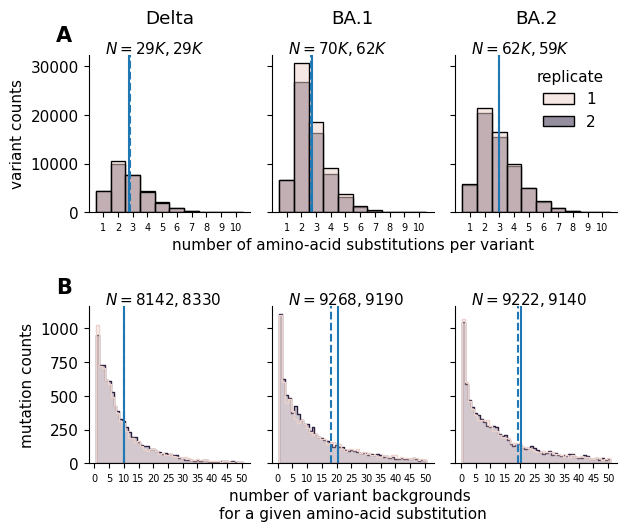

In [53]:
saveas = f"raw_data_summary_barcodes_backgrounds_hist"
logscale=False
fig, ax = plt.subplots(2,3, sharex="row", sharey="row", figsize=[6.4, 5.5])

condition_title = {
    "Delta":"Delta",
    "Omicron_BA1" : "BA.1",
    "Omicron_BA2" : "BA.2"
}

row = 0
for col, (condition, condition_df) in enumerate(func_score_df.groupby("condition")):
    iter_ax = ax[row, col]
    
    mut_df_replicates = condition_df.query("aa_substitutions != ''")
    mut_df_replicates = mut_df_replicates.assign(
        num_muts = [
            len(aa_subs.split())
            for aa_subs in mut_df_replicates.aa_substitutions
        ]
    )
    
    sns.histplot(mut_df_replicates.query("num_muts <= 10"), x="num_muts", ax=iter_ax, hue="replicate", discrete=True)
    for rep, rep_df in mut_df_replicates.groupby("replicate"):
        mean = rep_df['num_muts'].mean()
        iter_ax.axvline(mean, linestyle=("-" if rep == 1 else "--"))
    
    if logscale: iter_ax.set_yscale('log')
    if col != 2: 
        iter_ax.get_legend().remove()
    n_rep1 = len(mut_df_replicates.query("replicate == 1"))//1000
    n_rep2 = len(mut_df_replicates.query("replicate == 2"))//1000
    iter_ax.text(
        0.1, 1.1, 
        f"$N={n_rep1}K, {n_rep2}K$", 
        ha="left", va="top", 
        transform=iter_ax.transAxes
    )
    xscale = "number of amino-acid substitutions per variant" if col == 1 else ""
    iter_ax.set_xlabel(xscale)
    
    ylabel = f"variant counts" if col == 0 else ""
    iter_ax.set_ylabel(ylabel)
    iter_ax.set_xticks(
        [i+1 for i in range(10)],
        labels=[i+1 for i in range(10)], 
        ha="center",
        size=7,
        rotation=0
    )
    sns.despine(ax=iter_ax)
    iter_ax.set_title(condition_title[condition], y=1.15)

row = 1
collapsed_bc_df = func_score_df.groupby(
    ["replicate", "condition", "aa_substitutions"]
).aggregate("mean").reset_index()
for col, (condition, condition_df) in enumerate(collapsed_bc_df.groupby("condition")):
    iter_ax = ax[row, col]
    mut_df_replicates = pd.DataFrame()
    for rep, rep_df in condition_df.groupby("replicate"):
        
        times_seen = (
            rep_df["aa_substitutions"].str.split().explode().value_counts()
        )
        if (times_seen == times_seen.astype(int)).all():
            times_seen = times_seen.astype(int)
        times_seen = pd.DataFrame(times_seen)
        times_seen.index.name = f"mutation"
        mut_df_replicates = pd.concat([mut_df_replicates, times_seen.assign(replicate=rep).reset_index()])

    sns.histplot(
        mut_df_replicates.query("count <= 50"), 
        x="count", 
        ax=iter_ax, 
        element='step', 
        hue="replicate", 
        discrete=True
    )
    
    for rep, rep_df in mut_df_replicates.groupby("replicate"):
        mean = rep_df['count'].mean()
        iter_ax.axvline(mean, linestyle=("-" if rep == 1 else "--"))
        
    iter_ax.get_legend().remove()
    n_rep1 = len(mut_df_replicates.query("replicate == 1"))
    n_rep2 = len(mut_df_replicates.query("replicate == 2"))
    iter_ax.text(
        0.1, 1.1, 
        f"$N={n_rep1}, {n_rep2}$", 
        ha="left", va="top", 
        transform=iter_ax.transAxes
    )
    
    xscale = "number of variant backgrounds \nfor a given amino-acid substitution" if col == 1 else ""
    iter_ax.set_xlabel(xscale)
    
    ylabel = f"mutation counts" if col == 0 else ""
    iter_ax.set_ylabel(ylabel)
    
    xticks = [i for i in range(0, 51) if i % 5 == 0]
    iter_ax.set_xticks(
        xticks,
        labels=xticks, 
        ha="center",
        size=7,
        rotation=0
    )
    
    sns.despine(ax=iter_ax)

plt.tight_layout()

ax[0,0].text(
    -0.1, 1.06, 
    f"A", 
    ha="right", va="bottom", 
    size=15,
    weight="bold",
    transform=ax[0,0].transAxes
)
ax[1,0].text(
    -0.1, 1.06, 
    f"B", 
    ha="right", va="bottom", 
    size=15,
    weight="bold",
    transform=ax[1,0].transAxes
)

fig.subplots_adjust(hspace=.6)
fig.savefig(f"{output_dir}/{saveas}.pdf")
fig.savefig(f"{output_dir}/{saveas}.png")
plt.show()

Plot the correlation of variant functional scores (averaged across barcodes) between replicates in each condition, as well as the full distribution of functional scores.

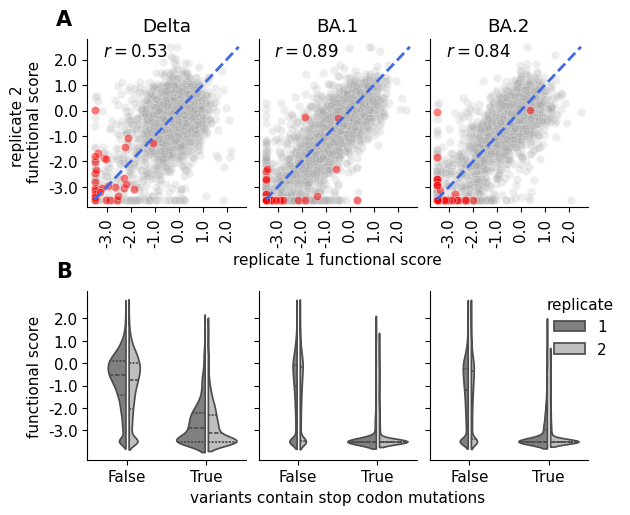

In [54]:
saveas = "replicate_functional_score_correlation_scatter"
pal = sns.color_palette('tab20')

fig, ax = plt.subplots(2,3, sharex="row", sharey="row", figsize=[6.4, 5.3])
collapsed_bc_df = func_score_df.groupby(
    ["replicate", "condition", "aa_substitutions"]
).aggregate("mean").reset_index()
collapsed_bc_df = collapsed_bc_df.assign(
    is_stop=[True if "*" in aasubs else False for aasubs in collapsed_bc_df.aa_substitutions]
)

is_stop_alpha_dict = {
    True : 0.5,
    False : 0.2
}

lim = [-3.8, 2.8]
ticks = np.linspace(-3, 2, 6)
for col, (condition, condition_df) in enumerate(collapsed_bc_df.groupby("condition")):
    
    row = 0
    iter_ax = ax[row, col]
    
    mut_df_replicates = reduce(
        lambda left, right: pd.merge(
            left, right, left_index=True, right_index=True, how="inner"
        ),
        [
            rep_df.rename({"func_score":f"rep_{rep}_func_score"}, axis=1).set_index("aa_substitutions")
            for rep, rep_df in condition_df.groupby("replicate") 
        ],
    )
    
    mut_df_replicates = mut_df_replicates.assign(
        is_stop=[True if "*" in aasubs else False for aasubs in mut_df_replicates.index.values]
    )
    mut_df_replicates = mut_df_replicates.assign(
        n_subs=[len(aasubs.split()) for aasubs in mut_df_replicates.index.values]
    )
    
    # alpha = [is_stop_alpha_dict[istp] for istp in mut_df_replicates.is_stop]
    for istp, color in zip([False, True], ["darkgrey", "red"]):
        sns.scatterplot(
            mut_df_replicates.query("is_stop == @istp"), 
            x="rep_1_func_score", 
            y="rep_2_func_score", 
            ax =iter_ax,
            c=color,
            alpha=is_stop_alpha_dict[istp],
            legend=False
        )
    
    iter_ax.plot([-3.5, 2.5], [-3.5, 2.5], "--", lw=2, c="royalblue")
    
    iter_ax.set_ylim(lim)
    iter_ax.set_xlim(lim)
    if col == 0:
        iter_ax.set_yticks(ticks, labels=ticks)
    iter_ax.set_xticks(ticks, labels=ticks, rotation=90)
    
    corr = pearsonr(mut_df_replicates["rep_1_func_score"], mut_df_replicates["rep_2_func_score"])[0]
    iter_ax.annotate(
        f"$r = {corr:.2f}$", 
        (0.1, 0.9), 
        xycoords="axes fraction", 
        fontsize=12
    )
    iter_ax.set_title(condition)
    # iter_ax.get_legend().remove()
    sns.despine(ax=iter_ax)
    
    row = 1
    iter_ax = ax[row, col]
    sns.violinplot(
        condition_df,
        x="is_stop",
        y="func_score",
        hue="replicate",
        split=True,
        gap=.1, inner="quart",
        palette=["0.5", "0.75"],
        ax=iter_ax
    )
    
    sns.despine(ax=iter_ax)
    if col != 2:
        iter_ax.get_legend().remove()
    else:
        iter_ax.legend(bbox_to_anchor = (1.25, 1.05), title="replicate")
    if col == 0:
        iter_ax.set_yticks(ticks, labels=ticks)

ax[0,0].set_xlabel("")
ax[0,0].set_ylabel("replicate 2 \n functional score")

ax[0,1].set_xlabel("replicate 1 functional score")
ax[0,1].set_title("BA.1")
ax[0,2].set_xlabel("")
ax[0,2].set_title("BA.2")

ax[1,0].set_xlabel("")
ax[1,0].set_ylabel("functional score")

ax[1,1].set_xlabel("variants contain stop codon mutations")
ax[1,2].set_xlabel("")
ax[1,2].set_ylabel("")
ax[1,1].set_ylabel("")

ax[0,0].text(
    -0.1, 1.06, 
    f"A", 
    ha="right", va="bottom", 
    size=15,
    weight="bold",
    transform=ax[0,0].transAxes
)
ax[1,0].text(
    -0.1, 1.06, 
    f"B", 
    ha="right", va="bottom", 
    size=15,
    weight="bold",
    transform=ax[1,0].transAxes
)

# fig.suptitle("Variant Functional Score \nReplicate Correlation")
plt.tight_layout()
fig.subplots_adjust(wspace=0.08, hspace = 0.5)
fig.savefig(f"{output_dir}/{saveas}.pdf")
fig.savefig(f"{output_dir}/{saveas}.png")
plt.show()

## Encode data for fitting

Next, we use the `multidms.Data` class to prep our data for fitting.

Instantiate an object for each of our two replicate training sets, and append them to a list 

In [55]:
datasets = []
for res, fsdf in func_score_df.groupby("replicate"):       

    start = time.time()

    # instantiate data object
    data = multidms.Data(
        fsdf,
        collapse_identical_variants="mean",       # take the average variant func score across barcode replicates
        alphabet=multidms.AAS_WITHSTOP_WITHGAP,   # 
        reference="Omicron_BA1",
        assert_site_integrity=False,
        verbose=True,
        nb_workers=num_data_workers,
        name=f"rep-{res}" 
    )

    end = time.time()
    prep_time = round(end-start)
    print(f"Finished, time: {prep_time}")

    datasets.append(data)

inferring site map for Delta


  0%|          | 0/29759 [00:00<?, ?it/s]

inferring site map for Omicron_BA1


  0%|          | 0/70610 [00:00<?, ?it/s]

inferring site map for Omicron_BA2


...

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


unknown cond wildtype at sites: [145, 70, 144, 143, 69, 211, 422, 26, 24, 25, 157, 158],
dropping: 10285 variantswhich have mutations at those sites.


invalid non-identical-sites: [371], dropping 1899 variants
Converting mutations for Delta


Converting mutations for Omicron_BA1
is reference, skipping
Converting mutations for Omicron_BA2


Finished, time: 71


Change the datasets colors - the only mutible thing about `Data` Objects.

In [56]:
# condition colors must be hex-encoded,
palette = [
    '#F97306',
    '#BFBFBF',
    '#9400D3'
]

conditions = [
    "Delta",
    "Omicron_BA1",
    "Omicron_BA2"
]

cc = {con:col for con, col in zip(conditions, palette)}
for data in datasets:
    data.condition_colors = cc

## Fit Models (Shrinkage Analysis)

For each replicate training set, initialize and fit a set models with variable lasso strength coefficients. Here, we use the `multidms.utils.fit_wrapper` function to handle the instatiation, and parameter fitting. Expand the cell output below to view the function docstring.

In [57]:
fit_params = {
    'output_activation': [output_activation],
    'scale_coeff_lasso_shift': scale_coeff_lasso_shift,
    'lower_bound' : [-3.5],
    'scale_coeff_ridge_beta': [scale_coeff_ridge_beta],
    'scale_coeff_ridge_ge_scale' : [scale_coeff_ridge_ge_scale],
    'maxiter': [maxiter],
    'init_theta_scale': [init_theta_scale],
    'init_theta_bias': [init_theta_bias],
}

fit_params["dataset"] = datasets


In [58]:
# simple cache check
if check_cache and os.path.exists(f"{output_dir}/full_models.pkl"):
    models = pickle.load(open(f"{output_dir}/full_models.pkl", "rb"))
    print("Loaded cached models")
else:
    _, _, models = multidms.fit_models(fit_params, n_threads=num_fit_threads)
    pickle.dump(models, open(f"{output_dir}/full_models.pkl", "wb"))
    
models

Loaded cached models


,epistatic_model,output_activation,init_theta_scale,init_theta_bias,n_hidden_units,lower_bound,PRNGKey,maxiter,scale_coeff_lasso_shift,scale_coeff_ridge_beta,dataset_name,model,fit_time
0,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.0,0.0,rep-1,Model(Model-0),5395
1,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.000005,0.0,rep-1,Model(Model-0),3827
2,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00001,0.0,rep-1,Model(Model-0),4860
3,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00002,0.0,rep-1,Model(Model-0),4411
4,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00004,0.0,rep-1,Model(Model-0),3066
5,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00008,0.0,rep-1,Model(Model-0),3695
6,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00016,0.0,rep-1,Model(Model-0),5401
7,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00032,0.0,rep-1,Model(Model-0),5399
8,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00064,0.0,rep-1,Model(Model-0),5424
9,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.0,0.0,rep-2,Model(Model-0),4698


The cell above saves the models and their relevant hyper-parameters in a `DataFrame` to a `pickle` binary file. Hense, If it's already been run, and you want to execute the code below _without_ re-fitting, the following cell will load that binary file.

In [59]:
model_collection = multidms.ModelCollection(models)
model_collection.fit_models

,epistatic_model,output_activation,init_theta_scale,init_theta_bias,n_hidden_units,lower_bound,PRNGKey,maxiter,scale_coeff_lasso_shift,scale_coeff_ridge_beta,dataset_name,model,fit_time,converged,Delta_loss_training,Omicron_BA1_loss_training,Omicron_BA2_loss_training,total_loss_training
0,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.0,0.0,rep-1,Model(Model-0),5395,False,0.223122,0.216851,0.219970,0.219981
1,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.000005,0.0,rep-1,Model(Model-0),3827,True,0.229420,0.233578,0.231071,0.231356
2,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00001,0.0,rep-1,Model(Model-0),4860,True,0.234773,0.244516,0.238132,0.239140
3,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00002,0.0,rep-1,Model(Model-0),4411,True,0.247654,0.262033,0.248541,0.252743
4,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00004,0.0,rep-1,Model(Model-0),3066,True,0.269704,0.286285,0.261438,0.272476
5,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00008,0.0,rep-1,Model(Model-0),3695,True,0.295015,0.312288,0.274260,0.293854
6,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00016,0.0,rep-1,Model(Model-0),5401,False,0.312373,0.311554,0.279132,0.301020
7,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00032,0.0,rep-1,Model(Model-0),5399,False,0.312449,0.311414,0.279376,0.301080
8,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.00064,0.0,rep-1,Model(Model-0),5424,False,0.312487,0.311416,0.279381,0.301095
9,Sigmoid,Identity,6.0,-3.5,5,None,0,50000,0.0,0.0,rep-2,Model(Model-0),4698,True,0.256591,0.170212,0.170595,0.199133


In [60]:
models["replicate"] = models.dataset_name.str.split("-").str[-1].astype(int)

Plot the model loss over training steps, as provided by `fit_wrapper`.

In [61]:
convergence_data = (
    model_collection
    .convergence_trajectory_df()
    .assign(
        scale_coeff_lasso_shift = lambda x: x.scale_coeff_lasso_shift.apply(lambda x: "{:.2e}".format(x))
    )
    .reset_index()
)
convergence_data

,step,loss,error,dataset_name,scale_coeff_lasso_shift
0,0,0.853256,inf,rep-1,0.00e+00
1,10,0.757026,0.042700,rep-1,0.00e+00
2,20,0.744331,0.040669,rep-1,0.00e+00
3,30,0.726832,0.101144,rep-1,0.00e+00
4,40,0.699843,0.071515,rep-1,0.00e+00
...,...,...,...,...,...
90013,49960,0.302583,0.000586,rep-2,6.40e-04
90014,49970,0.302583,0.000293,rep-2,6.40e-04
90015,49980,0.302583,0.000588,rep-2,6.40e-04
90016,49990,0.302583,0.000588,rep-2,6.40e-04


In [62]:
convergence_data.scale_coeff_lasso_shift.unique()

array(['0.00e+00', '5.00e-06', '1.00e-05', '2.00e-05', '4.00e-05',
       '8.00e-05', '1.60e-04', '3.20e-04', '6.40e-04'], dtype=object)

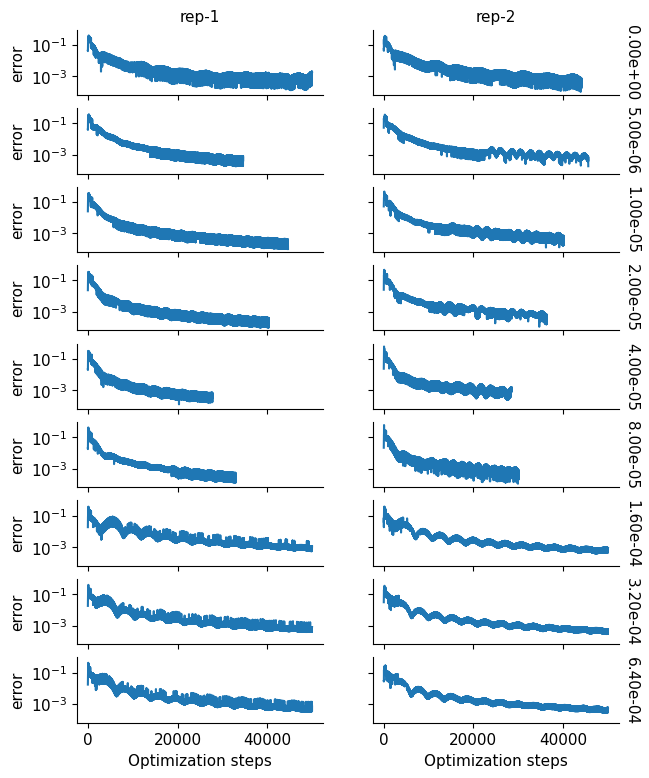

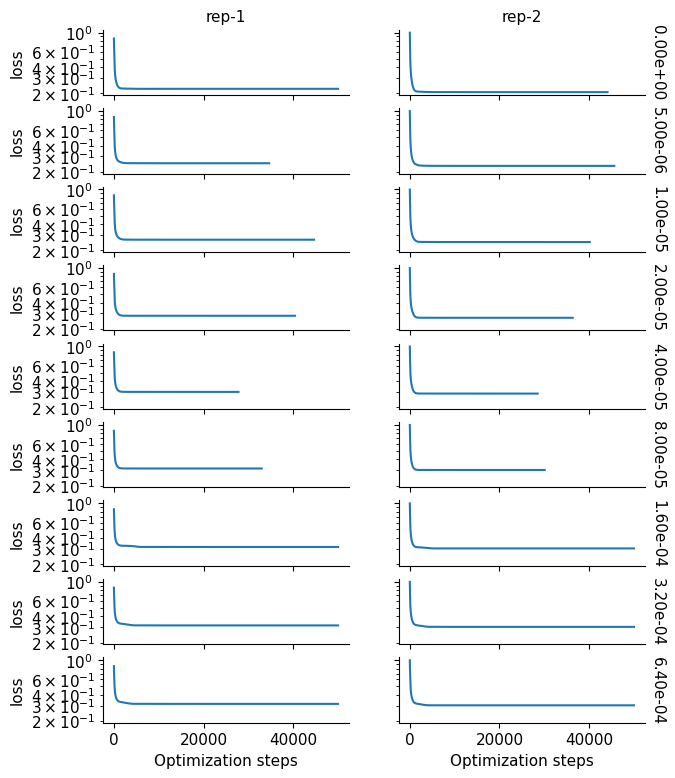

In [63]:
for metric in ["error", "loss"]:
    saveas=f"convergence_all_lasso_{metric}_lines"
    g = sns.FacetGrid(
        convergence_data, 
        col="dataset_name", 
        row="scale_coeff_lasso_shift", 
        height=1, 
        aspect=3.5,
        margin_titles=True
    )
    g.map_dataframe(sns.lineplot, x="step", y=metric)
    g.set_axis_labels("Optimization steps", metric)
    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.set(yscale="log")
    # plt.tight_layout()
    g.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
    g.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
    plt.show()
    # break

## Model Evaluation and Selection

In [64]:
chart, sparsity_df = model_collection.shift_sparsity(return_data=True, times_seen_threshold=times_seen_threshold, height_scalar=100) # TODO raise issue to fix height scalar
print(sparsity_df.head())
chart.save(f"{output_dir}/sparsity_chart.html")
chart

cache miss - this could take a moment
  dataset_name  scale_coeff_lasso_shift       mut_type    mut_param  sparsity
0        rep-1                 0.000000  nonsynonymous  shift_Delta  0.000000
1        rep-1                 0.000000           stop  shift_Delta  0.000000
2        rep-1                 0.000005  nonsynonymous  shift_Delta  0.159402
3        rep-1                 0.000005           stop  shift_Delta  0.523560
4        rep-1                 0.000010  nonsynonymous  shift_Delta  0.268940


alt.FacetChart(...)

In [15]:
chart, corr_df = model_collection.mut_param_dataset_correlation(width_scalar=200, return_data=True, times_seen_threshold=times_seen_threshold)
chart.save(f"{output_dir}/mut_param_dataset_corr_chart.html")
print(corr_df.head())
chart

      datasets   mut_param  correlation  scale_coeff_lasso_shift
0  rep-1,rep-2  beta_Delta     0.378259                 0.000000
0  rep-1,rep-2  beta_Delta     0.527847                 0.000005
0  rep-1,rep-2  beta_Delta     0.617656                 0.000010
0  rep-1,rep-2  beta_Delta     0.731213                 0.000020
0  rep-1,rep-2  beta_Delta     0.816353                 0.000040


alt.FacetChart(...)

In [ ]:
chosen_replicate_models = models.query("scale_coeff_lasso_shift == @chosen_lasso_strength")
saveas = "chosen_lasso_model_params_hist"
fig, ax = plt.subplots(2, 5, figsize=[15, 6.5])
for row, (idx, fit_series) in enumerate(chosen_replicate_models.iterrows()):
    model = fit_series["model"]
    params_to_viz = [f"beta_{c}" for c in model.data.conditions] + [f"shift_{c}" for c in model.data.conditions if c != model.data.reference]
    for col, param in enumerate(params_to_viz):
        iter_ax = ax[row, col]
        models.loc[4, "model"].plot_param_hist(param, times_seen_threshold=times_seen_threshold, ax=iter_ax, show=False)
        if "shift" in param:
            iter_ax.set_yscale("log")

plt.tight_layout()
fig.savefig(f"{output_dir}/{saveas}.pdf")
fig.savefig(f"{output_dir}/{saveas}.png")
plt.show()

## Cross Validation

In [45]:
train, test = [], {}
for replicate, fs_df in func_score_df.groupby("replicate"):

    dataset = fs_df.sample(frac=1, random_state=seed)
    train_split, test_split = dataset.iloc[:int(len(dataset) * train_frac)], dataset.iloc[int(len(dataset) * train_frac):]
    name = f"rep-{replicate}"
    
    train.append(
        multidms.Data(
            train_split,
            collapse_identical_variants="mean",
            reference="Omicron_BA1", 
            alphabet = multidms.AAS_WITHSTOP_WITHGAP, 
            verbose=False,
            nb_workers=num_data_workers,
            name = name
        )
    )

    test[name] = test_split


inferring site map for Delta


  0%|          | 0/23826 [00:00<?, ?it/s]

inferring site map for Omicron_BA1


  0%|          | 0/56513 [00:00<?, ?it/s]

inferring site map for Omicron_BA2


...

  0%|          | 0/47338 [00:00<?, ?it/s]

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


unknown cond wildtype at sites: [145, 70, 144, 143, 69, 211, 422, 26, 24, 25, 157, 158, 818],
dropping: 8227 variantswhich have mutations at those sites.


invalid non-identical-sites: [371], dropping 1495 variants
Converting mutations for Delta


Converting mutations for Omicron_BA1
is reference, skipping
Converting mutations for Omicron_BA2


In [46]:
if check_cache and os.path.exists(f"{output_dir}/cv_model_collection.pkl"):
    mc = pickle.load(open(f"{output_dir}/cv_model_collection.pkl", "rb"))
    print("Loaded cached models")
else: 
    fit_params["dataset"] = train 
    _, _, models_cv = multidms.model_collection.fit_models(fit_params, n_threads = num_fit_threads)
    mc = multidms.model_collection.ModelCollection(models_cv)
    mc.add_validation_loss(test, overwrite=True)
    pickle.dump(mc, open(f"{output_dir}/cv_model_collection.pkl", "wb"))

In [48]:
cross_validation_df = mc.get_conditional_loss_df()
cross_validation_df

,dataset_name,scale_coeff_lasso_shift,condition,loss,split
0,rep-1,0.0,Delta,0.202695,training
1,rep-1,0.000005,Delta,0.210363,training
2,rep-1,0.00001,Delta,0.215223,training
3,rep-1,0.00002,Delta,0.227296,training
4,rep-1,0.00004,Delta,0.251600,training
...,...,...,...,...,...
139,rep-2,0.00004,total,0.340642,validation
140,rep-2,0.00008,total,0.351948,validation
141,rep-2,0.00016,total,0.354419,validation
142,rep-2,0.00032,total,0.355069,validation


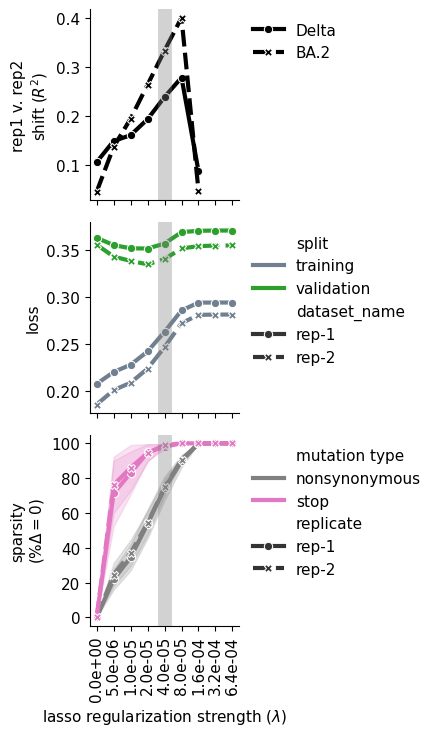

In [49]:
saveas="shrinkage_analysis_trace_plots_beta"

fig, ax = plt.subplots(3, figsize=[4.5, 7.5], sharex=True)

# replicate correlation
iter_ax = ax[0]
sns.lineplot(
    data=(
        corr_df
        .query("mut_param.str.contains('shift')")
        .rename({"mut_param":"shift params"}, axis=1)
        # .replace({"Data-1":"rep-1", "Data-2":"rep-2"})
        .replace({"shift_Delta":"Delta", "shift_Omicron_BA2":"BA.2"})
        .assign(
            scale_coeff_lasso_shift = [
                f"{l:.1e}" 
                for l in corr_df.query("mut_param.str.contains('shift')").scale_coeff_lasso_shift
            ],
            # correlation = lambda x: x.correlation**2
        )
        .reset_index(drop=True)
    ),
    x="scale_coeff_lasso_shift",
    y="correlation",
    style="shift params",
    markers=True,
    ax=iter_ax,
    linewidth=3,
    color="black"
)
iter_ax.set_ylabel("rep1 v. rep2\nshift $(R^2)$")
# move legend outside of plot
iter_ax.legend(
    bbox_to_anchor = (1, 1), 
    loc='upper left', 
    frameon=False
)



# plot loss
iter_ax = ax[1]
sns.lineplot(
    data = (
        cross_validation_df.query("condition=='total'")
        .assign(
            # lasso_strength = [f"{l:.1e}" for l in sparsity_df.scale_coeff_lasso_shift]
            # lasso_strength = lambda x: f"{x.scale_coeff_lasso_shift:.1e}"
            lasso_strength = lambda x: x['scale_coeff_lasso_shift'].apply(lambda y: f'{y:.1e}')
        )
    ),
    x="lasso_strength",
    y="loss",
    ax=iter_ax,
    hue="split",
    style="dataset_name",
    palette={"training":"slategrey", "validation":"#2CA02C"},
    markers=True,
    linewidth=3
)
# move legend outside of plot
iter_ax.legend(
    bbox_to_anchor = (1, 1), 
    loc='upper left', 
    frameon=False
)


# plot sparsity
iter_ax = ax[2]
sns.lineplot(
    data=(
        sparsity_df
        .rename({"dataset_name":"replicate"}, axis=1)
        .rename({"mut_param":"shift params", "mut_type":"mutation type"}, axis=1)
        # .replace({"Data-0":"rep-1", "Data-1":"rep-2"})
        .replace({"nonsynonymous":"nonsynonymous", "stop":"stop"})
        .replace({"shift_Delta":"Delta", "shift_Omicron_BA2":"BA.2"})
        .assign(
            scale_coeff_lasso_shift = [f"{l:.1e}" for l in sparsity_df.scale_coeff_lasso_shift],
            sparsity_percent = lambda x: x.sparsity * 100,
        )
    ),
    x="scale_coeff_lasso_shift",
    y="sparsity_percent",
    hue="mutation type",
    style="replicate",
    palette={"nonsynonymous":"grey", "stop":"#E377C2"},
    markers=True,
    legend=True,
    ax=iter_ax,
    linewidth=3
)
# move legend outside of plot
iter_ax.legend(
    bbox_to_anchor = (1, 1), 
    loc='upper left', 
    frameon=False
)
# rotate x labels
iter_ax.set_xticklabels(
    iter_ax.get_xticklabels(), 
    rotation=90, 
    ha='center'
)
iter_ax.set_ylabel("sparsity\n$(\%\Delta=0)$")
iter_ax.set_xlabel(f"lasso regularization strength ($\lambda$)")

for axes in ax:
    axes.axvline(
        f"{chosen_lasso_strength:.1e}", 
        color="grey",
        linewidth=10,
        alpha=0.35
    )

sns.despine(fig)
plt.tight_layout()
# plt.tight_layout()
fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
# plt.show()

plt.show()

## Global epistasis fits

Here, we take a look at the fit of the sigmoidal global epistasis function (at the chosen lasso coefficient of 5e-5) to the data.

For each replicate at the chosen lasso strength, we get the training data predictions using `model.get_variants_df`, and use `model.get_condition_params` paried with `model.model_components` for visualizing the global epistasis function with the current model parameters. See the function docs strings for the relevant details of each.

In [18]:
chosen_replicate_models = models.query("scale_coeff_lasso_shift == @chosen_lasso_strength")
replicate_data = {}
for row_idx, replicate_row in chosen_replicate_models.iterrows():
    model = replicate_row["model"]

    # get training data variants and their respective 
    mut_df_replicates = model.get_variants_df(phenotype_as_effect=False)

    # find the low/high bound of the training data and use those to make
    # global epistasis predictions across the range for plotting
    xlb, xub = [-1, 1] + np.quantile(mut_df_replicates.predicted_latent, [0.05, 1.0])
    additive_model_grid = np.linspace(xlb, xub, num=1000)

    # make predictions on hypothetical data points between lower, and upper bound
    current_params = model.get_condition_params(model.data.reference)
    latent_preds = model.model_components["g"](current_params["theta"], additive_model_grid)
    shape = (additive_model_grid, latent_preds)   

    # save and organize the data for plotting
    replicate_data[replicate_row.replicate] = {
        "variants_df" : mut_df_replicates,
        "wildtype_df" : model.wildtype_df,
        "epistasis_shape" : shape,
        "condition_colors" : model.data.condition_colors
    }

In [19]:
replicate_data.keys()

dict_keys([1, 2])

Plot the observed functional scores of a random sample of all variants (20%), as function of both latent phenotype prediction (top), and functional score phenotype prediction (bottom).

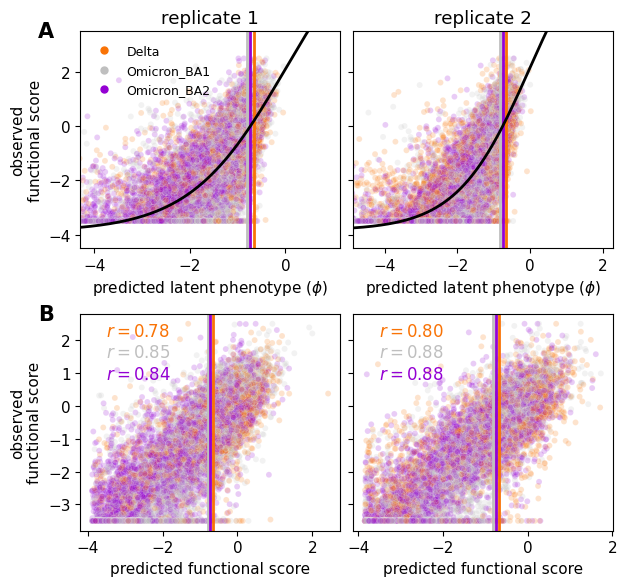

In [20]:
saveas="global_epistasis_and_prediction_correlations"
fig, ax = plt.subplots(2,2, figsize=[6.4,6], sharey='row')    

row=0
for replicate, data in replicate_data.items():

    iter_ax = ax[row, replicate-1]
    sns.scatterplot(
        data=data["variants_df"].sample(frac=0.2),
        x="predicted_latent",
        y=f"func_score",
        hue="condition",
        palette=model.data.condition_colors,
        ax=iter_ax,
        legend=False,
        size=5,
        alpha=0.2,
        # lw=3
    )
    
    for condition, values in data["wildtype_df"].iterrows():
        iter_ax.axvline(
            values.predicted_latent,
            label=condition,
            c=model.data.condition_colors[condition],
            lw=2,
        )
    
    iter_ax.plot(*data["epistasis_shape"], color="k", lw=2)
    
    xlb, xub = [-1, 1] + np.quantile(data["variants_df"].predicted_latent, [0.05, 1.0])
    ylb, yub = [-1, 1] + np.quantile(data["variants_df"].func_score, [0.05, 1.0])
    iter_ax.set_xlim([xlb, xub])
    iter_ax.set_ylim([ylb, yub])
    iter_ax.set_title(f"replicate {replicate}")
    iter_ax.set_ylabel("observed\nfunctional score")
    iter_ax.set_xlabel("predicted latent phenotype ($\phi$)")

row=1
for replicate, data in replicate_data.items():

    iter_ax = ax[row, replicate-1]
    sns.scatterplot(
        data=data["variants_df"].sample(frac=0.1),
        x="predicted_func_score",
        y=f"func_score",
        hue="condition",
        palette=model.data.condition_colors,
        ax=iter_ax,
        legend=False,
        size=5,
        alpha=0.2
    )
    
    for condition, values in data["wildtype_df"].iterrows():
        iter_ax.axvline(
            values.predicted_func_score,
            label=condition,
            c=model.data.condition_colors[condition],
            lw=2,
        )
    
    iter_ax.set_ylabel("observed\nfunctional score")
    iter_ax.set_xlabel("predicted functional score")

    start_y = 0.9
    for param, cdf in data["variants_df"].groupby("condition"):
        r = pearsonr(
            cdf["predicted_func_score"],
            cdf["func_score"]
        )[0]
        iter_ax.annotate(
            f"$r = {r:.2f}$",
            (0.1, start_y),
            xycoords="axes fraction",
            fontsize=12,
            c=model.data.condition_colors[param],
        )
        start_y += -0.1


elements = [
    mlines.Line2D([], [], color=color, marker='o', linestyle='None',markersize=5, label=condition)
    for condition, color in replicate_data[1]["condition_colors"].items()
]


ax[0, 0].legend(
    handles=elements, 
    bbox_to_anchor = (0., .99), 
    loc='upper left', 
    frameon=False, 
    fontsize=9
)
    
    
plt.tight_layout()
fig.subplots_adjust(wspace=0.05)

ax[0,0].text(
    -0.1, 1.00, 
    f"A", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=ax[0,0].transAxes
)
ax[1,0].text(
    -0.1, 1.00, 
    f"B", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=ax[1,0].transAxes
)


fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
plt.show()

## Shifted mutations (interactive altair chart)

The easiest way to view shifted mutations is to create an interactive `altair` chart using `multidms.plot.mut_shift_plot`. This function can take a single model, or a collection of models in a dictionary if you want to visualize the aggregated (mean) results of shared mutations between models. Toggle the drop down for the cell below to see details on using this function. 

In [21]:
help(multidms.ModelCollection.mut_param_heatmap)

Help on function mut_param_heatmap in module multidms.model_collection:

mut_param_heatmap(self, query=None, mut_param='shift', aggregate_func='mean', inner_merge_dataset_muts=True, times_seen_threshold=0, phenotype_as_effect=True, **kwargs)
    Create lineplot and heatmap altair chart
    across replicate datasets.
    This function optionally applies a given `pandas.query`
    on the fit_models dataframe that should result in a subset of
    fit's which make sense to aggregate mutational data across, e.g.
    replicate datasets.
    It then computes the mean or median mutational parameter value
    ("beta", "shift", or "predicted_func_score")
    between the remaining fits. and creates an interactive altair chart.
    
    
    Note that this will throw an error if the queried fits have more
    than one unique hyper-parameter besides "dataset_name".
    
    
    Parameters
    ----------
    query : str
        The query to apply to the fit_models dataframe. This should be
        

Here, we create the interactive chart by feeding the function a dictionary containing the two replicate models, and specifying:

1. times_seen_threshold = 1, meaning for a mutation to be included, it must be seen at least once in every condition
2. inlcude_beta = False, we only wish to see the shifted parameters visualized, not the respective _effect_ (beta) parameters. (note that respective effect values will be added as a tooltip when hovering over any shift mutation).

To view the chart, toggle the output of the cell below.

In [22]:
mc = multidms.ModelCollection(models.drop(columns="replicate"))

In [23]:
chart = mc.mut_param_heatmap(query=f"scale_coeff_lasso_shift == {chosen_lasso_strength}", times_seen_threshold=times_seen_threshold)
chart.save(f"{output_dir}/interactive_shift_chart.html")
chart

cache miss - this could take a moment


alt.VConcatChart(...)

## Shifted mutations (manually queried)

In [24]:
def get_wide_mutations_df(fit_dict, predicted_func_scores = False, how="inner", **kwargs):
    """
    Take a dictionary of fit objects, with key's as the prefix for individual
    replicate values, and merge then such that all individual and average mutation
    values are present in both.
    """
    # obtain and curate each of the replicate mutational dataframes
    mutations_dfs = []
    for replicate, fit in fit_dict.items():
        fit_mut_df = fit.get_mutations_df(return_split = False, **kwargs)
        # drop all "times seen" columns
        fit_mut_df = fit_mut_df.drop(
            [c for c in fit_mut_df.columns if "times_seen" in c], 
            axis=1
        )

        new_column_name_map = {c: f"{replicate}_{c}" for c in fit_mut_df.columns}
        fit_mut_df = fit_mut_df.rename(new_column_name_map, axis=1)

        mutations_dfs.append(fit_mut_df)

    # merge each of the replicate mutational dataframes
    mut_df = reduce(
        lambda left, right: pd.merge(
            left, right, left_index=True, right_index=True, how=how
        ),
        mutations_dfs,
    )
    return mut_df

# def get_long_mutations_df(fit_dict, **kwargs):
#     """
#     take a dictionary of fit objects, with key's as the prefix for individual
#     values, first, convert to wide using get_wide_mutations_df, 
#     then use pd.DataFrame.wide_to_long to convert it to a tall
#     dataframe using those prefixes
#     """

In [25]:
def combine_replicate_muts(fit_dict, predicted_func_scores = False, how="inner", **kwargs):
    """
    Take a dictionary of fit objects, with key's as the prefix for individual
    replicate values, and merge then such that all individual and average mutation
    values are present in both.
    """
    # obtain and curate each of the replicate mutational dataframes
    mutations_dfs = []
    for replicate, fit in fit_dict.items():
        fit_mut_df = fit.get_mutations_df(return_split = False, **kwargs)
        # drop all "times seen" columns
        fit_mut_df = fit_mut_df.drop(
            [c for c in fit_mut_df.columns if "times_seen" in c], 
            axis=1
        )

        new_column_name_map = {c: f"{replicate}_{c}" for c in fit_mut_df.columns}
        fit_mut_df = fit_mut_df.rename(new_column_name_map, axis=1)

        mutations_dfs.append(fit_mut_df)

    # merge each of the replicate mutational dataframes
    mut_df = reduce(
        lambda left, right: pd.merge(
            left, right, left_index=True, right_index=True, how=how
        ),
        mutations_dfs,
    )
    # return mut_df

    column_order = []
    # now compute replicate averages
    for c in fit.get_mutations_df(return_split=False, **kwargs).columns:

        if not predicted_func_scores and "predicted_func_score" in c:
            continue

        if any(key in c for key in ["mutation", "times_seen"]): # or "predicted_func_score" in c:
            continue
        
        cols_to_combine = [f"{replicate}_{c}" for replicate in fit_dict.keys()]

        # just keep one replicate wt, site, mut .. as they are shared.
        # if c in ["wts", "sites", "muts"]:
            # mut_df[c] = mut_df[cols_to_combine[0]]
            # mut_df.drop(cols_to_combine, axis=1, inplace=True)

        # take the average.
        # else:
        mut_df[f"avg_{c}"] = mut_df[cols_to_combine].mean(axis=1)
        column_order += cols_to_combine + [f"avg_{c}"]

    # parse_muts = self._mutparser.parse_mut
    mut_df["wts"], mut_df["sites"], mut_df["muts"] = zip(
        *mut_df.index.map(MutationParser(multidms.AAS_WITHSTOP_WITHGAP).parse_mut)
    )

    # return mut_df.loc[:, column_order]
    return mut_df.loc[:, ["wts", "sites", "muts"] + column_order]

In [26]:
mut_df_replicates = combine_replicate_muts(
    {
        f"{fit.dataset_name}".split("-")[-1]: fit.model
        for fit in models.query(f"scale_coeff_lasso_shift == {chosen_lasso_strength}").itertuples()
    },
    predicted_func_scores=True,
    how="inner",
    times_seen_threshold=times_seen_threshold
)
mut_df_replicates

,wts,sites,muts,1_beta_Delta,2_beta_Delta,avg_beta_Delta,1_beta_Omicron_BA1,2_beta_Omicron_BA1,avg_beta_Omicron_BA1,1_beta_Omicron_BA2,...,avg_shift_Omicron_BA2,1_predicted_func_score_Delta,2_predicted_func_score_Delta,avg_predicted_func_score_Delta,1_predicted_func_score_Omicron_BA1,2_predicted_func_score_Omicron_BA1,avg_predicted_func_score_Omicron_BA1,1_predicted_func_score_Omicron_BA2,2_predicted_func_score_Omicron_BA2,avg_predicted_func_score_Omicron_BA2
mutation,,,,,,,,,,,,,,,,,,,,,
M1I,M,1,I,-1.498671,-2.081987,-1.790329,-1.498671,-2.081987,-1.790329,-1.498671,...,0.000000,-1.764551,-2.338527,-2.051539,-2.634445,-3.060093,-2.847269,-3.082055,-3.464856,-3.273455
F2L,F,2,L,0.111630,0.167117,0.139374,0.111630,0.167117,0.139374,-0.011620,...,-0.061625,2.471608,3.313934,2.892771,0.293033,0.440146,0.366589,-1.003725,-0.993854,-0.998789
F2S,F,2,S,0.163658,0.119999,0.141829,0.163658,0.003719,0.083689,0.163658,...,0.000000,2.625827,3.179418,2.902622,0.433424,0.009509,0.221467,-0.603127,-1.333899,-0.968513
F2V,F,2,V,0.216551,-0.045866,0.085342,0.216551,-0.045866,0.085342,0.216551,...,0.000000,2.781609,2.696229,2.738919,0.578452,-0.116147,0.231152,-0.475623,-1.431000,-0.953311
V3A,V,3,A,-0.072554,-0.033802,-0.053178,-0.072554,-0.033802,-0.053178,-0.072554,...,0.000000,1.920846,2.731797,2.326322,-0.184039,-0.085803,-0.134921,-1.134872,-1.407637,-1.271255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S1252T,S,1252,T,-0.117924,-0.162477,-0.140201,-0.117924,-0.162477,-0.140201,-0.132782,...,-0.007429,1.784747,2.349941,2.067344,-0.296412,-0.401701,-0.349057,-1.260312,-1.648213,-1.454262
S1252V,S,1252,V,0.293275,-0.003174,0.145051,0.120910,0.144668,0.132789,0.051970,...,-0.062876,3.005371,2.821841,2.913606,0.317903,0.379557,0.348730,-0.862355,-1.162640,-1.012497
S1252W,S,1252,W,0.050877,0.227674,0.139275,0.050877,0.227674,0.139275,0.050877,...,0.000000,2.290560,3.484659,2.887610,0.132118,0.605674,0.368896,-0.864826,-0.860067,-0.862446


We need the sitemap of inferred wildtype amino acids at each site, for each condition. This is easily accessible via the `Model.data` attribute 

In [27]:
site_map = model.data.site_map
site_map.loc[10:20, :]

,Delta,Omicron_BA1,Omicron_BA2
10,L,L,L
11,V,V,V
12,S,S,S
13,S,S,S
14,Q,Q,Q
15,C,C,C
16,V,V,V
17,N,N,N
18,L,L,L
19,R,T,I


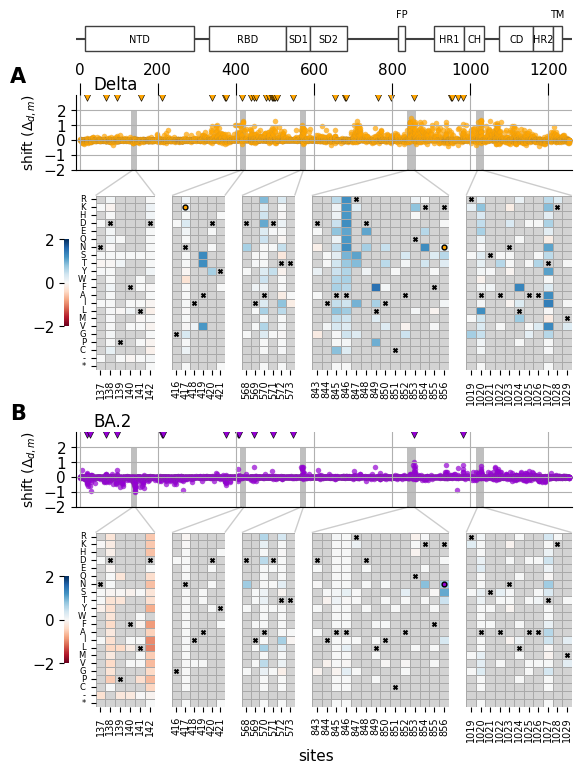

In [28]:
# some renaming and wrangling
mut_df_replicates["sense"] = ["stop" if mut == "*" else "nonsynonymous" for mut in mut_df_replicates.muts]
rename_omicron = {
    c:"_".join(c.split("_")[:2]+[c.split("_")[3]])
    for c in mut_df_replicates.columns if "Omicron" in c
}
mut_df_replicates.rename(rename_omicron, axis=1, inplace=True)
site_map = site_map.reset_index().rename(
    {"index":"sites", "Omicron_BA2": "BA2", "Omicron_BA1":"BA1"}, axis=1
).set_index("sites")

saveas = "shift_by_site_heatmap_zoom"

site_ranges = {
    "zoom1" : [137, 142],
    "zoom2" : [416, 421],
    "zoom3" : [568, 573],
    "zoom4" : [843, 856],
    "zoom5" : [1019, 1029]
}

# heatmap ax width ratios
width_ratios = [(end-start) for key, (start, end) in site_ranges.items()]

# make the first one a little bigger for the color bar
width_ratios[0] += width_ratios[0] * 0.5


# Plot domain architecture in primary sequence
# based on structure papers (Gobeil et al., 2022, Molecular Cell)
# (Duan et al., 2020, Frotiers in Immunology)
domain_dict = {
    'NTD' : [13, 293],
    'RBD' : [330, 528],
    'SD1' : [528, 590],
    'SD2' : [590, 685],
    'FP' : [815, 834],
    'HR1' : [907, 985],
    'CH' : [985, 1035],
    'CD' : [1075, 1162],
    'HR2' : [1162, 1211],
    'TM' : [1211, 1234],
}

sort_order = [
    "R","K","H","D","E","Q","N","S",
    "T","Y","W","F","A","I","L","M",
    "V","G","P","C","-","*"
]
if down_sample is not False:
    sort_order = [
        "R","K","H","D","E","Q","N","S",
        "T","Y","W","F","A","I","L","M",
        "V","G","P","C"#,"-","*"
    ]

fig = plt.figure( figsize=[6.4, 9])
axs = fig.subplot_mosaic(
    [
        ["Annotation"]*5,
        ["Delta"]*5,
        [f"{k}_Delta" for k in list(site_ranges.keys())],
        [f"{k}_Delta" for k in list(site_ranges.keys())],
        ["."]*5,
        ["BA2"]*5,
        [f"{k}_BA2" for k in list(site_ranges.keys())],
        [f"{k}_BA2" for k in list(site_ranges.keys())]
    ],
    
    height_ratios=[
        1.5, 
        2, 
        2, 
        2,
        0.3,
        2,
        2, 
        2
    ],
    empty_sentinel=".",
    # set the width ratios between the columns
    width_ratios=width_ratios,
    gridspec_kw={
        "wspace": 0.20,
        "hspace": 0.4,
    }
)

# derived from
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/axes_zoom_effect.html
def connect_bbox(bbox1, bbox2,
                 loc1a, loc2a, loc1b, loc2b,
                 prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {
            **prop_lines,
            "alpha": prop_lines.get("alpha", 1) * 0.2,
            "clip_on": False,
        }

    c1 = BboxConnector(
        bbox1, bbox2, loc1=loc1a, loc2=loc2a, clip_on=False, **prop_lines)
    c2 = BboxConnector(
        bbox1, bbox2, loc1=loc1b, loc2=loc2b, clip_on=False, **prop_lines)

    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)

    p = BboxConnectorPatch(bbox1, bbox2,
                           loc1a=loc1a, loc2a=loc2a, loc1b=loc1b, loc2b=loc2b,
                           clip_on=False,
                           **prop_patches)

    return c1, c2, bbox_patch1, bbox_patch2, p

def zoom_effect03(ax1, ax2, xmin, xmax, **kwargs):

    mybbox1 = ax1.bbox
    
    bbox = Bbox.from_extents(xmin, 0, xmax, 1)
    mybbox2 = TransformedBbox(bbox, ax2.get_xaxis_transform())

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.2}

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1, mybbox2,
        loc1a=2, loc2a=3, loc1b=1, loc2b=4,
        prop_lines=kwargs, prop_patches=prop_patches)

    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p

#############
# sitewise
#############


pal = sns.color_palette('colorblind')
cs = ['darkviolet', 'orange']
cs = {
    'BA2' : 'darkviolet', 
    'Delta' : 'orange'
}

# Plot per-site metric
metric_prefix = 'max_abs_shift_'
for (i, homolog) in enumerate(['BA2', 'Delta']):

    sns.scatterplot(
        x='sites', 
        y=f'avg_shift_{homolog}',
        data=mut_df_replicates, 
        s=15,
        alpha=0.7,
        edgecolor="grey",
        linewidth=0.05,
        ax=axs[homolog], 
        color=cs[homolog],
        label=""
    )
    
    nis = site_map.query(f"{homolog} != BA1")
    sns.scatterplot(
        x='sites', 
        y=np.repeat(2.9, len(nis)),
        data=nis, 
        s=30,
        ax=axs[homolog],
        marker='v',
        facecolor=cs[homolog], 
        edgecolor="k"
    )

    axs[homolog].grid()
    axs[homolog].set(
        xlim=[-10,1260],
        ylim=[-2, 3],
        yticks=[-2, -1, 0, 1, 2],
    )
    sns.despine(ax=axs[homolog])
    
    axs[homolog].tick_params(
        axis='x', 
        bottom=False,
        labelbottom=False,
        labeltop=True if homolog == "Delta" else False,
        top=True if homolog == "Delta" else False,
        size=9
    )
    axs[homolog].set_xlabel(None)
    axs[homolog].set_ylabel('shift ($\Delta_{d,m}$)', size=10)


axs["BA2"]._shared_axes['x'].join(axs["BA2"], axs["Delta"])

plot_rectangles = True
for zoom, site_range in site_ranges.items():
    if not plot_rectangles:
        continue
    (site_i, site_j) = site_range
    for (i, homolog) in enumerate(['BA2', 'Delta']):
        rect = patches.Rectangle(
            (site_i-5, -2), site_j-site_i+11, 4,
            edgecolor='none', facecolor='0.75', zorder=0
        )
        axs[homolog].add_patch(rect)
        
        
#############
# Annotation
#############

for (domain, (start, end)) in domain_dict.items():
    rectangle = patches.Rectangle((start, 1), end-start, 2, edgecolor='0.25', facecolor='white')
    axs["Annotation"].add_patch(rectangle)
    rx, ry = rectangle.get_xy()
    cx = rx + rectangle.get_width()/2.0
    cy = ry - 0.05 + rectangle.get_height()/2.0
    if domain in ['FP', 'TM']:
        cy += 2
    axs["Annotation"].annotate(
        domain, (cx, cy), color='black', ha='center', va='center',
        fontsize=7
    )

axs["Annotation"].set(ylim=[-0.5,4], yticks=[])
sns.despine(left=True, bottom=True, ax=axs["Annotation"])

axs["Annotation"].sharex(axs["BA2"])
axs["Annotation"].axhline(2, c='0.25', zorder=0)
axs["Annotation"].xaxis.set_tick_params(which='both', bottom=False, labelbottom=False, labeltop=False)

#############
# Heatmap
#############

for (i, homolog) in enumerate(['Delta', 'BA2']):
    
    df_shifts_wide = mut_df_replicates.pivot(
        index='muts', 
        columns='sites', 
        values=f'avg_shift_{homolog}'
    ).loc[sort_order, :]

    for zoom, (start, end) in site_ranges.items():
        
        iter_ax = axs[f"{zoom}_{homolog}"]
        iter_ax.set_facecolor("lightgrey")
        sites = [s for s in list(range(start, end+1)) if s in df_shifts_wide.columns]
        
        sns.heatmap(
            df_shifts_wide.loc[:, sites], 
            cbar=True if zoom == "zoom1" else False,
            cbar_kws={
                "shrink": 0.5, 
                "location":'left',
                'anchor': (-1.5, 0.5),
                'label' : None
            },
            ax = iter_ax,
            linewidth=.5, 
            linecolor="darkgrey",
            center=0,
            cmap='RdBu',
            vmin=-2.0,
            vmax=2.0,
            xticklabels=False,
            yticklabels=False,
        )

        for i, site in enumerate(sites):
            for j, mut in enumerate(sort_order):
                
                is_ref_wt = True if mut == site_map.loc[site,"BA1"] else False
                if is_ref_wt:
                    iter_ax.scatter(
                        [i+0.5], 
                        [j+0.5], 
                        marker="x", 
                        s=8, 
                        c="black"
                    )
                is_nis = (
                    True 
                    if mut ==  site_map.loc[site,homolog] and
                    mut !=  site_map.loc[site,"BA1"]
                    else False
                )
                
                if is_nis:
                    iter_ax.scatter(
                        [i+0.5], 
                        [j+0.5], 
                        marker="o", 
                        s=12, 
                        facecolors=cs[homolog],
                        edgecolors="black"
                    )

        if zoom != "zoom1":
            axs[f"{zoom}_{homolog}"].tick_params(axis='y', left=False, labelleft=False)
            sns.despine(left=True, bottom=True, ax=axs[f"{zoom}_{homolog}"])  
        else:
            axs[f"{zoom}_{homolog}"].set_yticks(
                [s+0.5 for s in range(len(sort_order))],
                labels=sort_order, 
                va="center",
                size=6
            )
            
        axs[f"{zoom}_{homolog}"].set_ylabel(None)
            
        if homolog != "Delta":
            axs[f"{zoom}_{homolog}"].sharex(axs[f"{zoom}_Delta"])
        axs[f"{zoom}_{homolog}"].set_xticks(
            [s+0.5 for s in range(len(sites))],
             labels=sites, 
             ha="center",
            rotation=90,
            size=7
        )
        axs[f"{zoom}_{homolog}"].set_xlabel(None)

for zoom, (start, end) in site_ranges.items():
    for homolog in ['Delta', 'BA2']:
        zoom_effect03(axs[f"{zoom}_{homolog}"], axs[homolog], start, end, alpha= 0.2)

fig.text(
    0.5, 0.05, 'sites',
    ha='center'
)

axs["Delta"].text(
    -0.1, 1.25, 
    f"A", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["Delta"].transAxes
)
axs["Delta"].text(
    0.035, 1.15, 
    f"Delta", 
    ha="left", va="center", 
    size=12,
    transform=axs["Delta"].transAxes
)

axs["BA2"].text(
    -0.1, 1.25, 
    f"B", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["BA2"].transAxes
)
axs["BA2"].text(
    0.035, 1.15, 
    f"BA.2", 
    ha="left", va="center", 
    size=12,
    transform=axs["BA2"].transAxes
)

fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
plt.show()

## Comparison of results to the naive approach (independent-condition fits)

Here we fit a model to each homolog individually, so that we may compare the results to our joint fitting process

TODO - plot the convergence and GE fits to the data.

In [66]:
func_score_df

,condition,replicate,aa_substitutions,n_subs,func_score
732900,Omicron_BA1,2,K97E I624T I770M,3,-3.5000
856004,Omicron_BA2,1,L276V,1,0.5966
215543,Delta,2,D215R F464L T678D K811I N1192H,5,-0.8570
239932,Delta,2,D178T,1,-3.5000
985852,Omicron_BA2,1,S172F Y655C L754F Y796C M1233T,5,-3.5000
...,...,...,...,...,...
1038434,Omicron_BA2,1,H1083Y,1,0.2731
998890,Omicron_BA2,1,L18D D142S A348T,3,-3.5000
170226,Delta,2,,0,-0.8050
199017,Delta,2,L1186M,1,0.5046


In [67]:
single_condition_datasets = []
for (replicate, condition), condition_fsdf in func_score_df.groupby(["replicate", "condition"]):
    start = time.time()
    data = multidms.Data(
        condition_fsdf,
        collapse_identical_variants="mean",
        alphabet=multidms.AAS_WITHSTOP_WITHGAP,
        reference=condition,
        assert_site_integrity=False,
        verbose=False,
        nb_workers=num_data_workers,
        name=f"{replicate}-{condition}"
    )
    data.condition_colors = cc
    single_condition_datasets.append(data)

inferring site map for Delta


  0%|          | 0/3381 [00:00<?, ?it/s]

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


unknown cond wildtype at sites: [],
dropping: 0 variantswhich have mutations at those sites.


invalid non-identical-sites: [], dropping 0 variants
Converting mutations for Delta
is reference, skipping
inferring site map for Omicron_BA1


...

invalid non-identical-sites: [], dropping 0 variants
Converting mutations for Omicron_BA1
is reference, skipping
inferring site map for Omicron_BA2


  0%|          | 0/6429 [00:00<?, ?it/s]

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


unknown cond wildtype at sites: [],
dropping: 0 variantswhich have mutations at those sites.


invalid non-identical-sites: [], dropping 0 variants
Converting mutations for Omicron_BA2
is reference, skipping


In [68]:
single_condition_datasets

[Data(1-Delta),
 Data(1-Omicron_BA1),
 Data(1-Omicron_BA2),
 Data(2-Delta),
 Data(2-Omicron_BA1),
 Data(2-Omicron_BA2)]

In [69]:
if check_cache and os.path.exists(f"{output_dir}/single_condition_models.pkl"):
    naive_models = pickle.load(open(f"{output_dir}/single_condition_models.pkl", "rb"))
    print("Loaded cached models")
else:
    single_condition_fit_params = fit_params.copy()
    single_condition_fit_params["scale_coeff_lasso_shift"] = [0]
    single_condition_fit_params["scale_coeff_ridge_beta"] = [0] # TODO ? 
    single_condition_fit_params["maxiter"] = [maxiter_single_condition]
    single_condition_fit_params["dataset"] = single_condition_datasets
    _, _, naive_models = multidms.fit_models(single_condition_fit_params, n_threads=num_fit_threads)     
    pickle.dump(naive_models, open(f"{output_dir}/single_condition_models.pkl", "wb"))

naive_models

Combine the results of the individual models

In [71]:
fit_dict = {row.dataset_name:row.model for _, row in naive_models.iterrows()}
fit_dict

{'1-Delta': Model(Model-0),
 '1-Omicron_BA1': Model(Model-0),
 '1-Omicron_BA2': Model(Model-0),
 '2-Delta': Model(Model-0),
 '2-Omicron_BA1': Model(Model-0),
 '2-Omicron_BA2': Model(Model-0)}

In [72]:
naive_mut_df = get_wide_mutations_df(
    fit_dict, 
    predicted_func_scores=True, 
    how="inner", 
    times_seen_threshold=times_seen_threshold
)

In [73]:
naive_mut_df

,1-Delta_beta_Delta,1-Delta_predicted_func_score_Delta,1-Omicron_BA1_beta_Omicron_BA1,1-Omicron_BA1_predicted_func_score_Omicron_BA1,1-Omicron_BA2_beta_Omicron_BA2,1-Omicron_BA2_predicted_func_score_Omicron_BA2,2-Delta_beta_Delta,2-Delta_predicted_func_score_Delta,2-Omicron_BA1_beta_Omicron_BA1,2-Omicron_BA1_predicted_func_score_Omicron_BA1,2-Omicron_BA2_beta_Omicron_BA2,2-Omicron_BA2_predicted_func_score_Omicron_BA2
mutation,,,,,,,,,,,,
L5A,-0.106336,-0.171814,0.084061,0.204927,-1.030534,-1.816509,0.970022,1.583880,-0.218608,-0.536280,-0.042803,-0.092691
L5I,0.374561,0.511125,0.315639,0.785841,1.180817,2.105387,0.280407,0.564492,-0.051548,-0.130901,0.556845,1.225537
L5S,-0.010067,-0.015737,-0.134656,-0.319345,0.168923,0.329298,-0.323624,-0.761698,0.068447,0.177801,0.214751,0.471728
L5Y,0.407251,0.549262,0.397842,0.995829,1.990168,3.041266,1.072472,1.695491,-0.572267,-1.292164,1.925314,3.612930
P9T,-2.140114,-5.434373,-0.170113,-0.401367,2.066525,3.105874,-0.833808,-2.162025,-0.110673,-0.277733,-0.329533,-0.693697
...,...,...,...,...,...,...,...,...,...,...,...,...
C1250Y,2.126872,1.586223,-0.241573,-0.563807,-0.043553,-0.084770,-0.309152,-0.725252,0.201602,0.535795,-0.972537,-1.844829
G1251V,0.908202,1.023182,0.851543,2.151422,0.325675,0.632547,-0.583525,-1.449792,-0.314875,-0.756121,0.334092,0.735996
S1252F,-0.021191,-0.033253,-0.051098,-0.122567,0.298541,0.580381,-0.107009,-0.239160,0.519573,1.442785,0.418420,0.922325


Using BA.1 as a reference fit, compute the difference of betas. Which is the naive approach to computing "shifts" in mutation effect between experiments without using the multidms joint modeling infrastructure. 

In [75]:
reference = "Omicron_BA1"
for i, condition in enumerate(["Delta", "Omicron_BA2"]): 
    for replicate in [1, 2]:
        reference_betas = naive_mut_df[f"{replicate}-{reference}_beta_{reference}"]
        condition_betas = naive_mut_df[f"{replicate}-{condition}_beta_{condition}"]
        naive_mut_df[f"{replicate}-{condition}_shift_{condition}"] = condition_betas - reference_betas
naive_mut_df

,1-Delta_beta_Delta,1-Delta_predicted_func_score_Delta,1-Omicron_BA1_beta_Omicron_BA1,1-Omicron_BA1_predicted_func_score_Omicron_BA1,1-Omicron_BA2_beta_Omicron_BA2,1-Omicron_BA2_predicted_func_score_Omicron_BA2,2-Delta_beta_Delta,2-Delta_predicted_func_score_Delta,2-Omicron_BA1_beta_Omicron_BA1,2-Omicron_BA1_predicted_func_score_Omicron_BA1,2-Omicron_BA2_beta_Omicron_BA2,2-Omicron_BA2_predicted_func_score_Omicron_BA2,1-Delta_shift_Delta,2-Delta_shift_Delta,1-Omicron_BA2_shift_Omicron_BA2,2-Omicron_BA2_shift_Omicron_BA2
mutation,,,,,,,,,,,,,,,,
L5A,-0.106336,-0.171814,0.084061,0.204927,-1.030534,-1.816509,0.970022,1.583880,-0.218608,-0.536280,-0.042803,-0.092691,-0.190398,1.188629,-1.114595,0.175804
L5I,0.374561,0.511125,0.315639,0.785841,1.180817,2.105387,0.280407,0.564492,-0.051548,-0.130901,0.556845,1.225537,0.058922,0.331955,0.865179,0.608393
L5S,-0.010067,-0.015737,-0.134656,-0.319345,0.168923,0.329298,-0.323624,-0.761698,0.068447,0.177801,0.214751,0.471728,0.124589,-0.392072,0.303580,0.146303
L5Y,0.407251,0.549262,0.397842,0.995829,1.990168,3.041266,1.072472,1.695491,-0.572267,-1.292164,1.925314,3.612930,0.009409,1.644738,1.592326,2.497581
P9T,-2.140114,-5.434373,-0.170113,-0.401367,2.066525,3.105874,-0.833808,-2.162025,-0.110673,-0.277733,-0.329533,-0.693697,-1.970001,-0.723135,2.236638,-0.218861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1250Y,2.126872,1.586223,-0.241573,-0.563807,-0.043553,-0.084770,-0.309152,-0.725252,0.201602,0.535795,-0.972537,-1.844829,2.368445,-0.510754,0.198020,-1.174139
G1251V,0.908202,1.023182,0.851543,2.151422,0.325675,0.632547,-0.583525,-1.449792,-0.314875,-0.756121,0.334092,0.735996,0.056660,-0.268650,-0.525868,0.648968
S1252F,-0.021191,-0.033253,-0.051098,-0.122567,0.298541,0.580381,-0.107009,-0.239160,0.519573,1.442785,0.418420,0.922325,0.029906,-0.626582,0.349639,-0.101154


In [76]:
mut_df_replicates = combine_replicate_muts(
    {
        f"{fit.dataset_name}".split("-")[-1]: fit.model
        for fit in models.query(f"scale_coeff_lasso_shift == {chosen_lasso_strength}").itertuples()
    },
    predicted_func_scores=False,
    how="inner",
    times_seen_threshold=times_seen_threshold
)

In [77]:
mut_df_replicates

,wts,sites,muts,1_beta_Delta,2_beta_Delta,avg_beta_Delta,1_beta_Omicron_BA1,2_beta_Omicron_BA1,avg_beta_Omicron_BA1,1_beta_Omicron_BA2,2_beta_Omicron_BA2,avg_beta_Omicron_BA2,1_shift_Delta,2_shift_Delta,avg_shift_Delta,1_shift_Omicron_BA2,2_shift_Omicron_BA2,avg_shift_Omicron_BA2
mutation,,,,,,,,,,,,,,,,,,
L5A,L,5,A,0.024050,-0.180932,-0.078441,0.033188,-0.032897,0.000145,-0.054782,0.052334,-0.001224,-0.009138,-0.148034,-0.078586,-0.087970,0.085231,-0.001370
L5S,L,5,S,-0.008760,0.086620,0.038930,0.019677,0.174539,0.097108,0.050649,0.030829,0.040739,-0.028436,-0.087919,-0.058178,0.030972,-0.143710,-0.056369
L18P,L,18,P,-0.056515,0.012663,-0.021926,0.199573,0.125965,0.162769,-0.329526,-0.155024,-0.242275,-0.256088,-0.113302,-0.184695,-0.529099,-0.280989,-0.405044
T19R,T,19,R,0.092558,-0.159863,-0.033652,0.091004,-0.048128,0.021438,-0.093328,-0.027136,-0.060232,0.001554,-0.111735,-0.055090,-0.184331,0.020993,-0.081669
R21G,R,21,G,-0.006896,0.187331,0.090217,-0.006912,0.132580,0.062834,-0.037194,0.100063,0.031434,0.000016,0.054751,0.027383,-0.030282,-0.032517,-0.031400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S1249F,S,1249,F,0.128902,0.160697,0.144800,-0.067595,-0.059033,-0.063314,-0.024298,-0.002415,-0.013357,0.196497,0.219730,0.208113,0.043297,0.056618,0.049957
G1251V,G,1251,V,0.162420,-0.239052,-0.038316,0.077786,-0.008977,0.034404,0.081793,0.124333,0.103063,0.084634,-0.230076,-0.072721,0.004007,0.133310,0.068658
S1252F,S,1252,F,0.123931,0.062723,0.093327,0.338325,0.084834,0.211579,0.053523,-0.101172,-0.023825,-0.214395,-0.022111,-0.118253,-0.284802,-0.186006,-0.235404


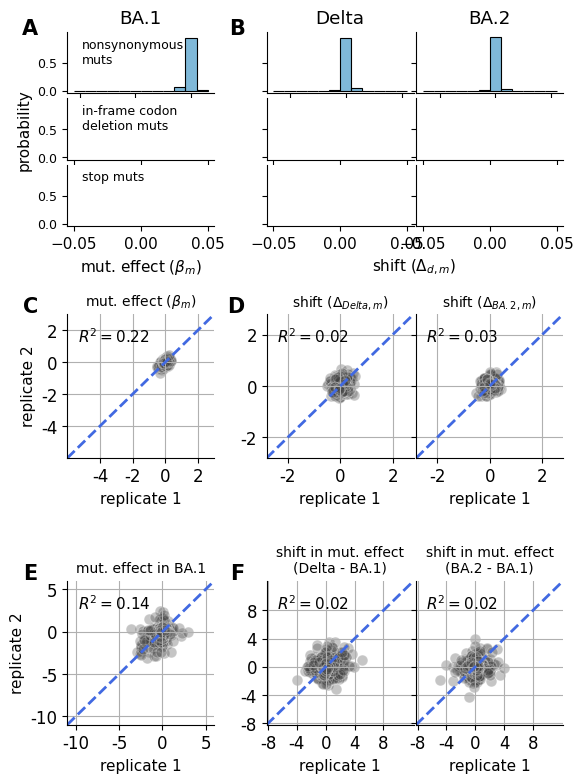

In [78]:
saveas="shift_distribution_correlation_naive"
pal = sns.color_palette('colorblind')
fig = plt.figure(figsize=[6.4, 9])

# the ratio of plot to divider between 
dist_sf = 3

# three rows of distributions
dist_rows = [[] for _ in range(3)]
for row, mut_type in enumerate(["m", "i", "n"]):
    dist_rows[row].extend([f"dist_{mut_type}_beta_Omicron_BA1"]*dist_sf)
    dist_rows[row].append(".")
    for param in ["shift_Delta", "shift_Omicron_BA2"]:
        dist_rows[row].extend([f"dist_{mut_type}_{param}"]*dist_sf)

# empty space row
number_of_rows = len(dist_rows[0])
empty_row = ["."] * len(dist_rows[0])

# correlation plot row
corr_row = ["corr_beta_Omicron_BA1"]*dist_sf+ ["."]
for param in ["shift_Delta", "shift_Omicron_BA2"]:
    corr_row.extend([f"corr_{param}"]*dist_sf)
    
# niave correlation plot row
# TODO fix the cond_param_cond nonsense
naive_corr_row = ["naive_corr_Omicron_BA1_beta_Omicron_BA1"]*dist_sf+ ["."]
for param in ["Delta_shift_Delta", "Omicron_BA2_shift_Omicron_BA2"]:
    naive_corr_row.extend([f"naive_corr_{param}"]*dist_sf)

axs = fig.subplot_mosaic(
    dist_rows+[empty_row, corr_row, empty_row, naive_corr_row],
    height_ratios=[0.3, 0.3, 0.3] + [0.38, 0.7, 0.55, 0.7],
    empty_sentinel=".",
    gridspec_kw={
        "wspace": 0.05,
        "hspace": 0.05,
    }
)

query_dict = {
    "m" : "muts != '*' and muts != '-'",
    "i" : "muts == '-'",
    "n" : "muts == '*'"
}

bins_dict = {
    "beta_Omicron_BA1" : np.arange(-5.25, 1.0, 0.5),
    "shift_Delta" : np.arange(-3.25, 3.25, 0.5),
    "shift_Omicron_BA2" : np.arange(-3.25, 3.25, 0.5)
}

#################
# DIshiftTRIBUTIONshift
#################
mut_df_replicates["sense"] = ["stop" if mut == "*" else "nonsynonymous" for mut in mut_df_replicates.muts]

prefix = "avg"
bins = np.arange(-5.25, 1.0, 0.5)
# df = mut_df_replicates.copy()
# print(mut_df_replicates)
mut_df_replicates["avg_beta_Omicron_BA1"].clip(lower=-5, inplace=True)

for col, param in enumerate(["beta_Omicron_BA1", "shift_Delta", "shift_Omicron_BA2"]):
    for row, mut_type in enumerate(["m", "i", "n"]):
        
        iter_ax = axs[f"dist_{mut_type}_{param}"]
        sns.histplot(
            mut_df_replicates.query(query_dict[mut_type]), 
            x=f"{prefix}_{param}", 
            ax=iter_ax,
            stat='probability',
            bins=bins_dict[param],
            label="stop",
            color="red" if mut_type == "n" else pal.as_hex()[row],
            alpha=0.5
        )
        iter_ax.set_ylim(-0.05,1.05)
        
        # remove the ylabel from all but the first column
        if col != 0: 
            iter_ax.tick_params(axis='y', labelleft=False)
        iter_ax.set_yticks(
            [0.0, 0.5], [0.0, 0.5], rotation=0, ha="right",size=9
        )
            
        if col != 0 or row != 1:
            iter_ax.set_ylabel(None)
        else:
            iter_ax.set_ylabel("probability")
        
        # remove the x labels from all but bottom
        if row != 2:
            iter_ax.tick_params(axis='x', labelbottom=False)
            iter_ax.set_xlabel(None)

        iter_ax.set_xlabel(None)
        
        sns.despine(ax=iter_ax)
        
axs["dist_n_beta_Omicron_BA1"].set_xlabel(r"mut. effect $(\beta_{m})$")
axs["dist_n_beta_Omicron_BA1"].xaxis.set_label_coords(0.5, -.5)

axs["dist_m_beta_Omicron_BA1"].text(
    0.1, 0.9, 
    f"nonsynonymous\nmuts", 
    ha="left", va="top", 
    size=9,
    transform=axs["dist_m_beta_Omicron_BA1"].transAxes
)
axs["dist_i_beta_Omicron_BA1"].text(
    0.1, 0.9, 
    f"in-frame codon\ndeletion muts", 
    ha="left", va="top", 
    size=9,
    transform=axs["dist_i_beta_Omicron_BA1"].transAxes
)
axs["dist_n_beta_Omicron_BA1"].text(
    0.1, 0.9, 
    f"stop muts", 
    ha="left", va="top", 
    size=9,
    transform=axs["dist_n_beta_Omicron_BA1"].transAxes
)

axs["dist_n_shift_Delta"].set_xlabel('shift ($\Delta_{d,m}$)')
axs["dist_n_shift_Delta"].xaxis.set_label_coords(1.0, -.5)

axs["dist_m_shift_Delta"].set_title("Delta")
axs["dist_m_shift_Omicron_BA2"].set_title("BA.2")

#################
# CORRELATIONshift
#################

data = mut_df_replicates.dropna().copy()
data['1_beta_Omicron_BA1'].clip(lower=-5, inplace=True)
data['2_beta_Omicron_BA1'].clip(lower=-5, inplace=True)
# plot the correlations of parameters
for col, param in enumerate(["beta_Omicron_BA1", "shift_Delta", "shift_Omicron_BA2"]):
    iter_ax = axs[f"corr_{param}"]
    x, y = data[f"1_{param}"], data[f"2_{param}"]
    sns.scatterplot(
        data = data,
        x = f"1_{param}",
        y = f"2_{param}",
        ax=iter_ax,
        s=60, 
        alpha=0.3,     
        c='0.25'
    )
    
    # remove y labels from all but first column
    if col != 0: 
        
        if col == 2:
            iter_ax.tick_params(axis='y', labelleft=False)
        iter_ax.set_ylabel(None)
        
        lim = [-2.8, 2.8]
        ticks = [-2, 0, 2]
        
        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(
            ticks, ticks, size=12
        )        
        iter_ax.set_xticks(
            ticks, ticks, rotation=0, size=12
        )
            # line of equivilence
        iter_ax.plot(
            lim, 
            lim,
            linestyle="--", 
            lw=2,
            c='royalblue'
        )
        
    else:
        lim = [-6, 3]
        ticks = [-4, -2, 0, 2]
        
        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(
            ticks, ticks, size=12
        )        
        iter_ax.set_xticks(
            ticks, ticks, rotation=0, size=12
        )
            # line of equivilence
        iter_ax.plot(
            lim, 
            lim,
            linestyle="--", 
            lw=2,
            c='royalblue'
        )
        
        iter_ax.set_ylabel("replicate 2")
        
    iter_ax.set_xlabel("replicate 1")
    iter_ax.grid()

    
    corr = pearsonr(x, y)[0]**2
    iter_ax.annotate(
        f"$R^2 = {corr:.2f}$", 
        (0.07, 0.8), 
        xycoords="axes fraction", 
        fontsize=11
    )
    sns.despine(ax=iter_ax)
    
#################
# NAIVE CORRELATIONshift
#################

data = naive_mut_df.dropna().copy()
data["1-Omicron_BA1_beta_Omicron_BA1"].clip(lower=-10, inplace=True)
data["2-Omicron_BA1_beta_Omicron_BA1"].clip(lower=-10, inplace=True)

# plot the correlations of parameters
for col, param in enumerate(["Omicron_BA1_beta_Omicron_BA1", "Delta_shift_Delta", "Omicron_BA2_shift_Omicron_BA2"]):
    iter_ax = axs[f"naive_corr_{param}"]
    x, y = data[f"1-{param}"], data[f"2-{param}"]
    sns.scatterplot(
        data = data,
        x = f"1-{param}",
        y = f"2-{param}",
        ax=iter_ax,
        s=60, 
        alpha=0.3,     
        c='0.25'
    )
    
    # remove y labels from all but first column
    if col != 0: 
        
        if col == 2:
            iter_ax.tick_params(axis='y', labelleft=False)
        iter_ax.set_ylabel(None)
        
        lim = [-8.2, 12.2]
        ticks = range(-8, 12, 4)
        
        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(
            ticks, ticks, size=12
        )        
        iter_ax.set_xticks(
            ticks, ticks, rotation=0, size=12
        )
            # line of equivilence
        iter_ax.plot(
            lim, 
            lim,
            linestyle="--", 
            lw=2,
            c='royalblue'
        )
        
    else:
        lim = [-11, 6]
        ticks = range(-10, 6, 5)
        
        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(
            ticks, ticks, size=12
        )        
        iter_ax.set_xticks(
            ticks, ticks, rotation=0, size=12
        )
            # line of equivilence
        iter_ax.plot(
            lim, 
            lim,
            linestyle="--", 
            lw=2,
            c='royalblue'
        )
        
        iter_ax.set_ylabel("replicate 2")
        
    iter_ax.set_xlabel("replicate 1")
    iter_ax.grid()

    
    corr = pearsonr(x, y)[0]**2
    iter_ax.annotate(
        f"$R^{2} = {corr:.2f}$", 
        (0.07, 0.8), 
        xycoords="axes fraction", 
        fontsize=11
    )
    sns.despine(ax=iter_ax)




# Add subpanel labels
axs["dist_m_beta_Omicron_BA1"].text(
    -0.2, 1.05, 
    f"A", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["dist_m_beta_Omicron_BA1"].transAxes
)


axs["dist_m_shift_Delta"].text(
    -0.15, 1.05, 
    f"B", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["dist_m_shift_Delta"].transAxes
)

axs["corr_beta_Omicron_BA1"].text(
    -0.2, 1.05, 
    f"C", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["corr_beta_Omicron_BA1"].transAxes
)

axs["corr_shift_Delta"].text(
    -0.15, 1.05, 
    f"D", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["corr_shift_Delta"].transAxes
)

axs["naive_corr_Omicron_BA1_beta_Omicron_BA1"].text(
    -0.2, 1.05, 
    f"E", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["naive_corr_Omicron_BA1_beta_Omicron_BA1"].transAxes
)

axs["naive_corr_Delta_shift_Delta"].text(
    -0.15, 1.05, 
    f"F", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["naive_corr_Delta_shift_Delta"].transAxes
)

# titles
axs["dist_m_beta_Omicron_BA1"].set_title("BA.1")
axs["corr_beta_Omicron_BA1"].set_title(r"mut. effect $(\beta_{m})$", size=10)
axs["corr_shift_Delta"].set_title("shift ($\Delta_{Delta, m}$)", size=10)
axs["corr_shift_Omicron_BA2"].set_title("shift ($\Delta_{BA.2, m}$)", size=10)

axs["naive_corr_Omicron_BA1_beta_Omicron_BA1"].set_title("mut. effect in BA.1", size=10)
axs["naive_corr_Delta_shift_Delta"].set_title("shift in mut. effect\n(Delta - BA.1)", size=10)
axs["naive_corr_Omicron_BA2_shift_Omicron_BA2"].set_title("shift in mut. effect\n(BA.2 - BA.1)", size=10)

fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')

plt.show()  

## Comparison to linear model

In [80]:
if check_cache and os.path.exists(f"{output_dir}/linear_models_full.pkl"):
    linear_models = pickle.load(open(f"{output_dir}/linear_models_full.pkl", "rb"))
    print("Loaded cached models")
else:
    fit_params_linear = fit_params.copy()
    fit_params_linear["dataset"] = datasets
    fit_params_linear["epistatic_model"] = ["Identity"]
    _, _, linear_models = multidms.fit_models(fit_params_linear, n_threads=num_fit_threads)
    pickle.dump(linear_models, open(f"{output_dir}/linear_models_full.pkl", "wb"))

linear_models

In [81]:
model_collection_linear = multidms.ModelCollection(linear_models)

In [82]:
chart, sparsity_df = model_collection_linear.shift_sparsity(return_data=True, height_scalar=100) # TODO raise issue to fix height scalar
print(sparsity_df.head())
chart

cache miss - this could take a moment
  dataset_name  scale_coeff_lasso_shift       mut_type    mut_param  sparsity
0        rep-1                 0.000000  nonsynonymous  shift_Delta  0.001015
1        rep-1                 0.000000           stop  shift_Delta  0.000000
2        rep-1                 0.000005  nonsynonymous  shift_Delta  0.140711
3        rep-1                 0.000005           stop  shift_Delta  0.290323
4        rep-1                 0.000010  nonsynonymous  shift_Delta  0.143553


alt.FacetChart(...)

In [83]:
chart, corr_df = model_collection_linear.mut_param_dataset_correlation(width_scalar=200, return_data=True)
print(corr_df.head())
chart

      datasets   mut_param  correlation  scale_coeff_lasso_shift
0  rep-1,rep-2  beta_Delta     0.010858                 0.000000
0  rep-1,rep-2  beta_Delta     0.011321                 0.000005
0  rep-1,rep-2  beta_Delta     0.011749                 0.000010
0  rep-1,rep-2  beta_Delta     0.012674                 0.000020
0  rep-1,rep-2  beta_Delta     0.014784                 0.000040


alt.FacetChart(...)

In [84]:
if check_cache and os.path.exists(f"{output_dir}/linear_models_cv.pkl"):
    linear_mc = pickle.load(open(f"{output_dir}/linear_models_cv.pkl", "rb"))
    print("Loaded cached models")
else:
    fit_params_linear = fit_params.copy()
    fit_params_linear["epistatic_model"] = ["Identity"]
    fit_params_linear["dataset"] = train 
    _, _, linear_models_cv = multidms.model_collection.fit_models(fit_params_linear, n_threads = num_fit_threads)
    linear_mc = multidms.model_collection.ModelCollection(linear_models_cv)
    linear_mc.add_validation_loss(test, overwrite=True)
    pickle.dump(linear_mc, open(f"{output_dir}/linear_models_cv.pkl", "wb"))

In [ ]:

cross_validation_df = linear_mc.get_conditional_loss_df()
cross_validation_df.head()

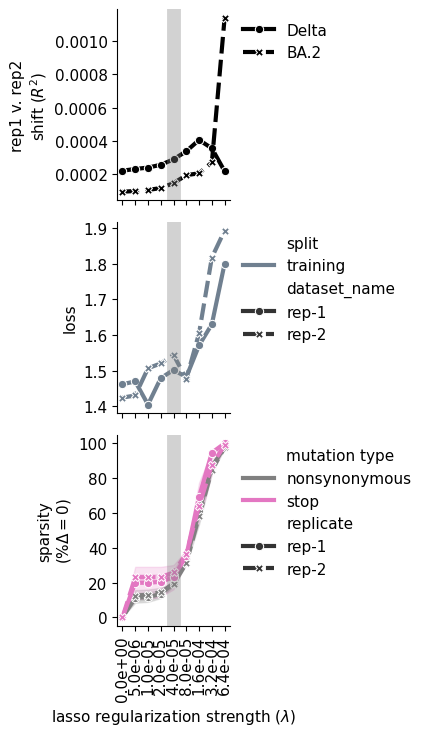

In [87]:

saveas="shrinkage_analysis_linear_models"

fig, ax = plt.subplots(3, figsize=[4.5, 7.5], sharex=True)

# replicate correlation
iter_ax = ax[0]
sns.lineplot(
    data=(
        corr_df
        .query("mut_param.str.contains('shift')")
        .rename({"mut_param":"shift params"}, axis=1)
        # .replace({"Data-1":"rep-1", "Data-2":"rep-2"})
        .replace({"shift_Delta":"Delta", "shift_Omicron_BA2":"BA.2"})
        .assign(
            scale_coeff_lasso_shift = [
                f"{l:.1e}" 
                for l in corr_df.query("mut_param.str.contains('shift')").scale_coeff_lasso_shift
            ],
            correlation = lambda x: x.correlation
        )
        .reset_index(drop=True)
    ),
    x="scale_coeff_lasso_shift",
    y="correlation",
    style="shift params",
    markers=True,
    ax=iter_ax,
    linewidth=3,
    color="black"
)
iter_ax.set_ylabel("rep1 v. rep2\nshift $(R^2)$")
# move legend outside of plot
iter_ax.legend(
    bbox_to_anchor = (1, 1), 
    loc='upper left', 
    frameon=False
)



# plot loss
iter_ax = ax[1]
sns.lineplot(
    data = (
        cross_validation_df.query("condition=='total'")
        .assign(
            # lasso_strength = [f"{l:.1e}" for l in sparsity_df.scale_coeff_lasso_shift]
            # lasso_strength = lambda x: f"{x.scale_coeff_lasso_shift:.1e}"
            lasso_strength = lambda x: x['scale_coeff_lasso_shift'].apply(lambda y: f'{y:.1e}')
        )
    ),
    x="lasso_strength",
    y="loss",
    ax=iter_ax,
    hue="split",
    style="dataset_name",
    palette={"training":"slategrey", "validation":"#2CA02C"},
    markers=True,
    linewidth=3
)
# move legend outside of plot
iter_ax.legend(
    bbox_to_anchor = (1, 1), 
    loc='upper left', 
    frameon=False
)


# plot sparsity
iter_ax = ax[2]
sns.lineplot(
    data=(
        sparsity_df
        .rename({"dataset_name":"replicate"}, axis=1)
        .rename({"mut_param":"shift params", "mut_type":"mutation type"}, axis=1)
        # .replace({"Data-0":"rep-1", "Data-1":"rep-2"})
        .replace({"nonsynonymous":"nonsynonymous", "stop":"stop"})
        .replace({"shift_Delta":"Delta", "shift_Omicron_BA2":"BA.2"})
        .assign(
            scale_coeff_lasso_shift = [f"{l:.1e}" for l in sparsity_df.scale_coeff_lasso_shift],
            sparsity_percent = lambda x: x.sparsity * 100,
        )
    ),
    x="scale_coeff_lasso_shift",
    y="sparsity_percent",
    hue="mutation type",
    style="replicate",
    palette={"nonsynonymous":"grey", "stop":"#E377C2"},
    markers=True,
    legend=True,
    ax=iter_ax,
    linewidth=3
)
# move legend outside of plot
iter_ax.legend(
    bbox_to_anchor = (1, 1), 
    loc='upper left', 
    frameon=False
)
# rotate x labels
iter_ax.set_xticklabels(
    iter_ax.get_xticklabels(), 
    rotation=90, 
    ha='center'
)
iter_ax.set_ylabel("sparsity\n$(\%\Delta=0)$")
iter_ax.set_xlabel(f"lasso regularization strength ($\lambda$)")

for axes in ax:
    axes.axvline(
        f"{chosen_lasso_strength:.1e}", 
        color="grey",
        linewidth=10,
        alpha=0.35
    )

sns.despine(fig)
plt.tight_layout()
# plt.tight_layout()
fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
# plt.show()

plt.show()

## Validation mutations

Next, we compare the results of the model to mutations tested individually in _in-vitro_

In [88]:
mut_df_replicates = combine_replicate_muts(
    {
        f"{fit.dataset_name}".split("-")[-1]: fit.model
        for fit in models.query(f"scale_coeff_lasso_shift == {chosen_lasso_strength}").itertuples()
    },
    predicted_func_scores=True,
    phenotype_as_effect=True,
    how="inner",
    times_seen_threshold=times_seen_threshold
)
mut_df_replicates

,wts,sites,muts,1_beta_Delta,2_beta_Delta,avg_beta_Delta,1_beta_Omicron_BA1,2_beta_Omicron_BA1,avg_beta_Omicron_BA1,1_beta_Omicron_BA2,...,avg_shift_Omicron_BA2,1_predicted_func_score_Delta,2_predicted_func_score_Delta,avg_predicted_func_score_Delta,1_predicted_func_score_Omicron_BA1,2_predicted_func_score_Omicron_BA1,avg_predicted_func_score_Omicron_BA1,1_predicted_func_score_Omicron_BA2,2_predicted_func_score_Omicron_BA2,avg_predicted_func_score_Omicron_BA2
mutation,,,,,,,,,,,,,,,,,,,,,
L5A,L,5,A,0.024050,-0.180932,-0.078441,0.033188,-0.032897,0.000145,-0.054782,...,-0.001370,-1.987393,-1.134568,-1.560981,0.081761,-0.085963,-0.002101,-4.094793,-3.401598,-3.748196
L5S,L,5,S,-0.008760,0.086620,0.038930,0.019677,0.174539,0.097108,0.050649,...,-0.056369,-2.055612,-0.457357,-1.256484,0.048454,0.458305,0.253380,-4.048200,-3.428639,-3.738420
L18P,L,18,P,-0.056515,0.012663,-0.021926,0.199573,0.125965,0.162769,-0.329526,...,-0.405044,-2.153288,-0.647826,-1.400557,0.493077,0.330596,0.411836,-4.197052,-3.645307,-3.921179
T19R,T,19,R,0.092558,-0.159863,-0.033652,0.091004,-0.048128,0.021438,-0.093328,...,-0.081669,-1.842123,-1.082594,-1.462358,0.224535,-0.125684,0.049426,-4.110743,-3.499453,-3.805098
R21G,R,21,G,-0.006896,0.187331,0.090217,-0.006912,0.132580,0.062834,-0.037194,...,-0.031400,-2.051762,-0.195246,-1.123504,-0.017005,0.347989,0.165492,-4.087327,-3.340070,-3.713698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S1249F,S,1249,F,0.128902,0.160697,0.144800,-0.067595,-0.059033,-0.063314,-0.024298,...,0.049957,-1.763556,-0.264811,-1.014183,-0.165864,-0.154087,-0.159975,-4.081776,-3.469620,-3.775698
G1251V,G,1251,V,0.162420,-0.239052,-0.038316,0.077786,-0.008977,0.034404,0.081793,...,0.068658,-1.690215,-1.276483,-1.483349,0.191865,-0.023479,0.084193,-4.033566,-3.307974,-3.670770
S1252F,S,1252,F,0.123931,0.062723,0.093327,0.338325,0.084834,0.211579,0.053523,...,-0.235404,-1.774363,-0.519118,-1.146741,0.834945,0.222485,0.528715,-4.046867,-3.585598,-3.816233


In [89]:
mut_df = (
    mut_df_replicates
    .assign(
        phenotypic_effect_Delta = 2**mut_df_replicates["avg_predicted_func_score_Delta"],
        phenotypic_effect_Omicron_BA2 = 2**mut_df_replicates["avg_predicted_func_score_Omicron_BA2"],
        phenotypic_effect_Omicron_BA1 = 2**mut_df_replicates["avg_predicted_func_score_Omicron_BA1"]
    )
    .reset_index()
)
mut_df[[c for c in mut_df.columns if "phenotypic_effect" in c]].describe()

,phenotypic_effect_Delta,phenotypic_effect_Omicron_BA2,phenotypic_effect_Omicron_BA1
count,364.000000,364.000000,364.000000
mean,0.389041,0.072819,0.987847
std,0.058789,0.004631,0.203639
min,0.226374,0.059794,0.425735
25%,0.348190,0.069959,0.876229
50%,0.384956,0.072746,0.996551
75%,0.425863,0.075830,1.094662
max,0.614011,0.087932,1.798300


IndexError: index 0 is out of bounds for axis 0 with size 0

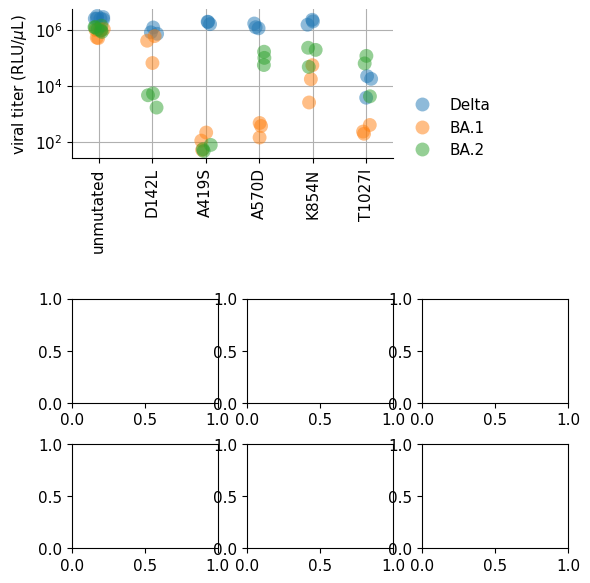

In [90]:
saveas="validation_titer_fold_change"

row1 = ['titer', 'titer', '.']
row2 = ['D142L', 'A419S', 'A570D'] 
row3 = ['K854N', 'T1027I', 'legend']
empty_row = ["."] * 3

fig = plt.figure( figsize=[6.4, 7])
axs = fig.subplot_mosaic(
    [row1, empty_row, row2, row3],
    height_ratios=[
        1, 0.39, 0.7, 0.7
    ],
    empty_sentinel=".",
    gridspec_kw={
        "wspace": 0.20,
        "hspace": 0.4,
    }
)

#############
# TITERS
#############

# Read in data
titers_df = pd.read_csv('data/viral_titers.csv')
titers_df.rename(
    columns={'RLUperuL':'titer', 'background':'homolog'},
    inplace=True
)

# Add a column giving the replicate and mutation
titers_df['replicate'] = titers_df['virus'].apply(lambda x: x[-1])
titers_df['mutation'] = titers_df['virus'].str.extract(r'_(\S+)_')
titers_df['mutation'].fillna('unmutated', inplace=True)
titers_df['mutation'].replace('142L', 'D142L', inplace=True)

# Plot data for a given mutation
validation_mutations = ['D142L', 'A419S', 'A570D', 'K854N', 'T1027I']
homologs = ['Delta', 'BA.1', 'BA.2']
replicates = ['1', '2', '3']
xticklabels = ['unmutated'] + validation_mutations
pal = sns.color_palette('colorblind')
hex_codes = pal.as_hex()
for (i, homolog) in enumerate(homologs):
    
    data = titers_df[(titers_df['homolog'] == homolog)]
    
    sns.stripplot(
        x='mutation', y='titer', data=data, ax=axs['titer'],
        order=xticklabels, s=10, alpha=0.5,
        hue='homolog', hue_order=['Delta', 'BA.1', 'BA.2'],
    )
    sns.boxplot(
        x='mutation', y='titer', data=data, ax=axs['titer'],
        order=xticklabels,
        showfliers=False, showbox=False, showcaps=False,
        medianprops={'visible': False}, #dict(color=hex_codes[i]),
        whiskerprops={'visible': False},
    )

handles, labels = axs['titer'].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axs['titer'].legend(by_label.values(), by_label.keys(), bbox_to_anchor=[1,0.5])

axs['titer'].set_yscale('log')
axs['titer'].set_yticks([1e2, 1e4, 1e6])
axs['titer'].set_xticklabels(axs['titer'].get_xticklabels(), rotation = 90)
axs['titer'].set_ylabel(r'viral titer (RLU/$\mu$L)')
axs['titer'].set_xlabel('')
axs['titer'].grid()
sns.despine(ax = axs['titer'])


#############
# FOLD CHANGE
#############

# Read in data
val_df = pd.read_csv('data/spike_validation_data.csv')

# Restructure the data
val_dict = {
    key : []
    for key in [
        'mutation', 'fold_change', 'homolog', 'replicate',
        'predicted_beta'
    ]
}
validation_mutations = ['D142L', 'A419S', 'A570D', 'K854N', 'T1027I']
for i, row in val_df.iterrows():
    for mutation in validation_mutations:
        homolog = row['background'].replace('.', '')
        homolog = "Omicron_" + homolog if "BA" in homolog else homolog

        val_dict['mutation'].append(mutation)
        val_dict['fold_change'].append(row[mutation])
        val_dict['homolog'].append(homolog)
        val_dict['replicate'].append(row['replicate'])

        if mutation in mut_df.mutation.values:
            predicted_beta = float(mut_df[
                mut_df['mutation'] == mutation
            ][f'phenotypic_effect_{homolog}'].values[0])
        else:
            predicted_beta = 0.0
        val_dict['predicted_beta'].append(predicted_beta)

val_df = pd.DataFrame(val_dict)
val_df['site'] = val_df['mutation'].apply(lambda x: int(x[1:-1]))
val_df['homolog'].replace('Omicron_BA1', 'BA.1', inplace=True)
val_df['homolog'].replace('Omicron_BA2', 'BA.2', inplace=True)
val_df.sort_values('site', inplace=True)

for (i, mutation) in enumerate(validation_mutations):
    data = val_df[val_df['mutation'] == mutation]
    iter_ax = axs[mutation]
    sns.scatterplot(
        x='predicted_beta', y='fold_change', data=data,
        hue='homolog', ax=iter_ax, s=100, alpha=0.7,
        hue_order=['Delta', 'BA.1', 'BA.2']
    )
    iter_ax.set(
        title=mutation, xlabel='', ylabel='',
        yscale='log', ylim=[1e-5,2], yticks=[1, 1e-2, 1e-4],
    )
    iter_ax.set_xscale('log', base=2)
    iter_ax.set_xlim([0.1, 1.3])
    iter_ax.set_xticks([2**-3, 2**-2, 2**-1, 2**0])

    iter_ax.grid()
    iter_ax.get_legend().remove()
    sns.despine(ax=iter_ax)
    
    if mutation in ['D142L', 'A419S']:
        iter_ax.tick_params(axis="x", labelbottom=False)
    
    if mutation not in ['D142L', 'K854N']:
        iter_ax.tick_params(axis="y", labelleft=False)

fig.text(
    0.5, 0.02, "predicted enrichment ratio in DMS experiment \n(mutant : unmutated)",
    ha='center'
)
fig.text(
    0.000, 0.31, 'fold change in viral titer\n (mutant : unmutated)',
    va='center', rotation='vertical'
)
axs["legend"].set_axis_off()

axs["titer"].text(
    -0.05, 1.15, 
    f"A", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["titer"].transAxes
)
axs["D142L"].text(
    -0.1, 1.25, 
    f"B", 
    ha="right", va="center", 
    size=15,
    weight="bold",
    transform=axs["D142L"].transAxes
)

fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
plt.show()

## Model-reference choice comparison

Here, we fit each of the replicate dataset as before, but we also fit models where using Delta and BA.2 as a reference to show the model is robust to choice of reference 

In [91]:
variable_reference_datasets = []

for reference in ["Delta", "Omicron_BA1", "Omicron_BA2"]:
    for replicate, rep_fsdf in func_score_df.groupby("replicate"):
        
        start = time.time()

        # initialize data object
        data = multidms.Data(
            rep_fsdf,
            collapse_identical_variants="mean",
            alphabet=multidms.AAS_WITHSTOP_WITHGAP,
            reference=reference,
            assert_site_integrity=False,
            verbose=False,
            nb_workers=num_data_workers,
            name=f"{replicate}-{reference}"
        )
        data.condition_colors = cc
        variable_reference_datasets.append(data)


inferring site map for Delta


  0%|          | 0/3381 [00:00<?, ?it/s]

inferring site map for Omicron_BA1


  0%|          | 0/4898 [00:00<?, ?it/s]

inferring site map for Omicron_BA2


...

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


unknown cond wildtype at sites: [499, 737, 824, 431, 223, 144, 535, 543, 143, 672, 70, 590, 211, 584, 295, 665, 330, 69, 694, 901, 1083, 480, 734, 432, 662, 914, 763, 502, 663, 994, 996, 920, 752, 801, 667, 40, 467, 574, 578, 670, 231, 974, 366, 454, 786, 802, 194, 238, 329, 377, 456, 1218, 145, 699, 816, 1030, 906, 283, 729, 351, 910, 546, 669, 1105, 508, 233, 326, 358, 511, 923, 931, 229, 762, 980, 561, 462, 903, 977, 1152, 24, 426, 461, 905, 966, 334, 437, 506, 510, 25, 433, 26, 664, 805, 491, 527, 57, 693, 781, 305, 562, 612, 927, 722, 602, 1053, 597, 1007, 770, 266, 423, 489, 965, 1119, 526, 528, 1082, 1064, 291, 749, 760, 157, 873, 158, 236, 1145, 725, 775, 744, 1028, 224, 277, 338, 587, 400, 497, 541, 565, 92, 107, 993, 1048, 1110, 970, 726, 934, 983, 304, 951, 947, 707, 276, 598, 425, 492, 605, 331, 542, 992, 589, 296, 1138, 644, 953, 742, 617, 559, 399, 418, 608, 721, 421, 610, 723, 201, 1015, 422, 756, 545, 817, 391, 896, 978, 997, 919, 759, 386, 797, 720, 595, 424, 387, 741,

invalid non-identical-sites: [156, 213, 339, 375, 376, 405, 440, 452, 498, 796, 27], dropping 954 variants
Converting mutations for Delta


Converting mutations for Omicron_BA1


Converting mutations for Omicron_BA2
is reference, skipping


In [92]:
if check_cache and os.path.exists(f"{output_dir}/variable_reference_models.pkl"):
    variable_reference_models = pickle.load(open(f"{output_dir}/variable_reference_models.pkl", "rb"))
    print("Loaded cached models")
else:
    variable_reference_fit_params = fit_params.copy()
    variable_reference_fit_params["dataset"] = variable_reference_datasets
    variable_reference_fit_params["scale_coeff_lasso_shift"] = [chosen_lasso_strength]
    _, _, variable_reference_models = multidms.fit_models(variable_reference_fit_params, n_threads=num_fit_threads)
    pickle.dump(variable_reference_models, open(f"{output_dir}/variable_reference_models.pkl", "wb"))

In [93]:
variable_reference_models = (
    variable_reference_models
    .assign(
        reference=lambda x: x.dataset_name.str.split("-").str[-1],
        replicate=lambda x: x.dataset_name.str.split("-").str[0]
    )
)

For each of the reference fits, compute parameters relative to a BA.1 reference

In [95]:
relative_params = pd.DataFrame()
homologs = ["Delta", "Omicron_BA1", "Omicron_BA2"]

# For each respective model fit 
for reference, replicate_models in variable_reference_models.groupby("reference"):
    
    # combine the replicate mutational 
    mut_df = combine_replicate_muts(
        {
            f"rep_{row.replicate}":row["model"] 
            for idx, row in replicate_models.iterrows()
        },
        times_seen_threshold = times_seen_threshold
    )
    
    mut_df = mut_df.copy()[[c for c in mut_df.columns if "avg" in c]]
    
    # Compute mut effect (beta+shift) relative to each homolog
    for homolog in homologs:
        if homolog == reference:
            mut_df[f"beta_{homolog}"] = mut_df[f"avg_beta_{reference}"]
        else:
            mut_df[f"beta_{homolog}"] = mut_df[f"avg_beta_{reference}"] + mut_df[f"avg_shift_{homolog}"]
       
    # Compute shifts relative to BA1 (betas_h - beta_BA1)
    for homolog in homologs:
        mut_df[f"shift_{homolog}"] = mut_df[f"beta_{homolog}"] - mut_df[f"beta_Omicron_BA1"]
    
    # drop un-neccessary columns
    mut_df.drop([c for c in mut_df.columns if "avg" in c], axis=1, inplace=True)
    
    mut_df = mut_df.assign(reference = reference)
    
    relative_params = pd.concat([relative_params, mut_df])

    
relative_params.drop(["beta_Delta", "beta_Omicron_BA2", "shift_Omicron_BA1"], axis=1, inplace=True)
relative_params.reference.replace({"Omicron_BA2":"BA2", "Omicron_BA1": "BA1"}, inplace=True)
relative_params

,beta_Omicron_BA1,shift_Delta,shift_Omicron_BA2,reference
mutation,,,,
L5A,-0.002479,-0.076297,0.004200,Delta
L5S,0.090758,-0.051416,-0.048921,Delta
L18P,0.171884,-0.199838,-0.424853,Delta
R19T,0.033145,-0.040624,0.208586,Delta
R21K,0.112917,-0.078026,0.019706,Delta
...,...,...,...,...
G1246V,0.046913,-0.065405,0.057436,BA2
S1249F,-0.111486,0.260700,0.126938,BA2
S1252F,0.216375,-0.131675,-0.257278,BA2


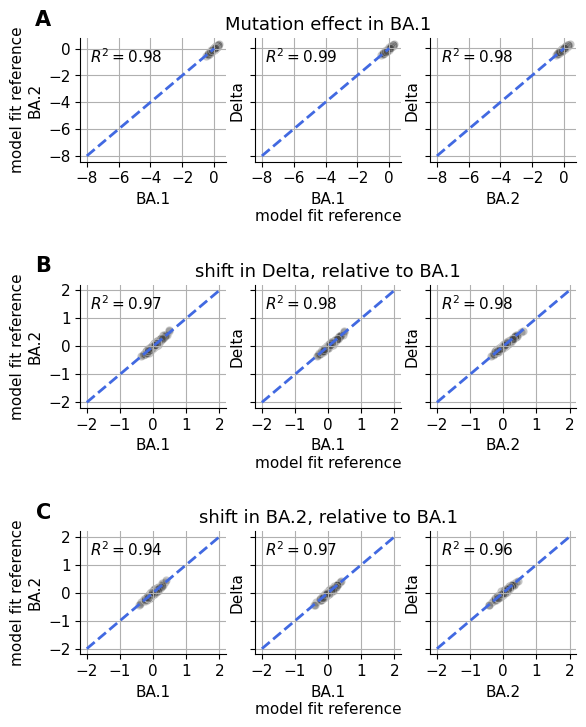

In [96]:
saveas = "reference_model_comparison_params_scatter"
parameters = ["beta_Omicron_BA1", "shift_Delta", "shift_Omicron_BA2"]


fig = plt.figure( figsize=[6.4, 8])
axs = fig.subplot_mosaic(
    [[f"{param}_{col}" for col in range(3)] for param in parameters],
    gridspec_kw={
        "wspace": 0.20,
        "hspace": 1.0,
    }
)

param_limits = {
    "beta_Omicron_BA1" : range(-8, 2, 2),
    "shift_Delta" : range(-2, 3),
    "shift_Omicron_BA2" : range(-2, 3) 
}

param_titles = {
    "beta_Omicron_BA1" : r"Mutation effect in BA.1",
    "shift_Delta" : "shift in Delta, relative to BA.1",
    "shift_Omicron_BA2" : "shift in BA.2, relative to BA.1"
}


for row, param in enumerate(parameters):
    
    # pivot to each fit on columns, drop NIS.
    data = relative_params.pivot(
        columns = "reference",
        values = param
    ).dropna()

    # plot each combination of fits
    for col, (x, y) in enumerate(combinations(data.columns, 2)):
        iter_ax = axs[f"{param}_{col}"]
        
        sns.scatterplot(
            data = data,
            x = x,
            y = y,
            ax = iter_ax,
            alpha=0.3,
            c='0.25'
        )
        
        corr = pearsonr(data[x], data[y])[0]**2
        iter_ax.annotate(
            f"$R^2 = {corr:.2f}$", 
            (0.07, 0.8), 
            xycoords="axes fraction", 
            fontsize=11
        )
        
        limits = param_limits[param]
        iter_ax.set_yticks(limits)
        iter_ax.set_xticks(limits)
        mmin, mmax = min(limits), max(limits)
        iter_ax.plot([mmin, mmax], [mmin, mmax], "--", lw=2, c="royalblue")
        label_fn = lambda x: x if x == "Delta" else f"{x[0]}{x[1]}.{x[2]}"
        
        
        xl = f"{label_fn(x)}"
        yl = f"{label_fn(y)}"
        if col == 1: xl += "\nmodel fit reference"
        if col == 0: yl = "model fit reference\n" + yl
        iter_ax.set_xlabel(xl)
        iter_ax.set_ylabel(yl)            
            
        
        
        iter_ax.grid()
        sns.despine(ax = iter_ax)
        
        if col != 0:
            iter_ax.tick_params("y", labelleft=False)
            
        if col == 1:
            iter_ax.set_title(param_titles[param], size=13)
            


for param, sub_anno in zip(parameters, ["A", "B", "C"]):
    iter_ax = axs[f"{param}_0"]    
    axs[f"{param}_0"].text(
        -0.2, 1.15, 
        sub_anno, 
        ha="right", va="center", 
        size=15,
        weight="bold",
        transform=iter_ax.transAxes
    )

fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
plt.show()

## Cumulative distribution of model sparsity

In [97]:
tall_mut_df_chosen = (
    mc.split_apply_combine_muts(query=f"scale_coeff_lasso_shift == {chosen_lasso_strength}", times_seen_threshold=times_seen_threshold)
    .reset_index()
    .rename(columns={"dataset_name":"replicate"})
    .assign(sense=lambda x: ["stop" if "*" in mut else "nonsynonymous" for mut in x.mutation])
    .melt(
        id_vars=["replicate", "mutation", "sense"],
        value_vars=["shift_Delta", "shift_Omicron_BA2"],
        var_name="condition",
        value_name="shift"
    )
    .replace({"shift_Delta":"Delta", "shift_Omicron_BA2":"Omicron_BA2"})
)
tall_mut_df_chosen

cache miss - this could take a moment


,replicate,mutation,sense,condition,shift
0,rep-1,A1016S,nonsynonymous,Delta,0.163465
1,rep-1,A1016T,nonsynonymous,Delta,-0.189288
2,rep-1,A1020D,nonsynonymous,Delta,0.176538
3,rep-1,A1020E,nonsynonymous,Delta,0.133687
4,rep-1,A1020G,nonsynonymous,Delta,0.354340
...,...,...,...,...,...
2827,rep-2,Y28H,nonsynonymous,Omicron_BA2,0.078424
2828,rep-2,Y369H,nonsynonymous,Omicron_BA2,0.078717
2829,rep-2,Y449H,nonsynonymous,Omicron_BA2,0.062859
2830,rep-2,Y501N,nonsynonymous,Omicron_BA2,-0.015956


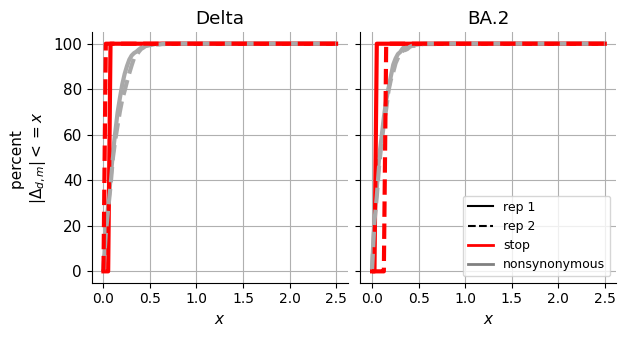

In [98]:
saveas = "percent_shifts_under_x_lineplot"
fig, ax = plt.subplots(1,2, figsize=[6.4,3.5], sharey='row')

condition_col = {
    "Delta" : 0,
    "Omicron_BA2" : 1
}

replicate_line_style = {
    "rep-1" : "-",
    "rep-2" : "--"
}

sense_colors = {
    "nonsynonymous" : "darkgrey",
    "stop" : "red"
}

t_points = np.linspace(0, 2.5, 100)
def perc_abs_lte(x, t):
    abs_x = np.abs(x)
    return len(abs_x[abs_x<=t]) / len(x) #)*100

for (condition, replicate, sense), mut_df_replicates in tall_mut_df_chosen.groupby(["condition", "replicate", "sense"]):
    iter_ax = ax[condition_col[condition]]
    lt_percentages = [perc_abs_lte(mut_df_replicates["shift"], t)*100 for t in t_points]
    iter_ax.plot(
        t_points, 
        lt_percentages,
        linestyle = replicate_line_style[replicate],
        color = sense_colors[sense],
        linewidth = 3
    )
    iter_ax.set_xticks(np.linspace(0,2.5,6),np.linspace(0,2.5,6), rotation=0, ha="center",size=10)
    sns.despine(ax=iter_ax)
    iter_ax.grid(visible=True)
    
ax[condition_col["Delta"]].set_title("Delta")
ax[condition_col["Omicron_BA2"]].set_title("BA.2")

ax[0].set_ylabel("percent \n$|\Delta_{d,m}| <= x$")
ax[0].set_xlabel("$x$")
ax[1].set_xlabel("$x$")

black_line = mlines.Line2D([], [], color='black', linestyle='-',
                          markersize=5, label='rep 1')
black_dashed = mlines.Line2D([], [], color='black',linestyle='--',
                          markersize=5, label='rep 2')
red_line = mlines.Line2D([], [], color='red', linewidth=2,linestyle='-',markersize=5, label='stop')
grey_line = mlines.Line2D([], [], color='grey',linewidth=2, linestyle='-',markersize=5, label='nonsynonymous')
ax[1].legend(
    handles=[black_line, black_dashed, red_line, grey_line], 
    bbox_to_anchor = (1, 0), 
    loc='lower right', 
    frameon=True, 
    fontsize=9
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.05)
fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
plt.show()

## Correlation of BA2 and Delta Shifts

In [99]:
mut_df_replicates = (
    combine_replicate_muts(
        {
            f"{fit.dataset_name}".split("-")[-1]: fit.model
            for fit in models.query(f"scale_coeff_lasso_shift == {chosen_lasso_strength}").itertuples()
        },
        times_seen_threshold=times_seen_threshold,
        how="inner"
    )
    .assign(
        sense=lambda x: ["stop" if "*" in mut else "nonsynonymous" for mut in x.muts]
    )
)
mut_df_replicates.head()

,wts,sites,muts,1_beta_Delta,2_beta_Delta,avg_beta_Delta,1_beta_Omicron_BA1,2_beta_Omicron_BA1,avg_beta_Omicron_BA1,1_beta_Omicron_BA2,2_beta_Omicron_BA2,avg_beta_Omicron_BA2,1_shift_Delta,2_shift_Delta,avg_shift_Delta,1_shift_Omicron_BA2,2_shift_Omicron_BA2,avg_shift_Omicron_BA2,sense
mutation,,,,,,,,,,,,,,,,,,,
L5A,L,5,A,0.024050,-0.180932,-0.078441,0.033188,-0.032897,0.000145,-0.054782,0.052334,-0.001224,-0.009138,-0.148034,-0.078586,-0.087970,0.085231,-0.001370,nonsynonymous
L5S,L,5,S,-0.008760,0.086620,0.038930,0.019677,0.174539,0.097108,0.050649,0.030829,0.040739,-0.028436,-0.087919,-0.058178,0.030972,-0.143710,-0.056369,nonsynonymous
L18P,L,18,P,-0.056515,0.012663,-0.021926,0.199573,0.125965,0.162769,-0.329526,-0.155024,-0.242275,-0.256088,-0.113302,-0.184695,-0.529099,-0.280989,-0.405044,nonsynonymous
T19R,T,19,R,0.092558,-0.159863,-0.033652,0.091004,-0.048128,0.021438,-0.093328,-0.027136,-0.060232,0.001554,-0.111735,-0.055090,-0.184331,0.020993,-0.081669,nonsynonymous
R21G,R,21,G,-0.006896,0.187331,0.090217,-0.006912,0.132580,0.062834,-0.037194,0.100063,0.031434,0.000016,0.054751,0.027383,-0.030282,-0.032517,-0.031400,nonsynonymous


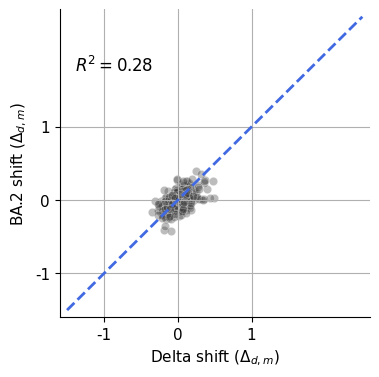

In [100]:
# data = mut_df_replicates.dropna()
saveas="shift_corr_Delta_BA2"
fig, ax = plt.subplots(1,figsize=[4,4])
lim = [-1.6, 2.6]
ticks = range(-1, 2)
sns.scatterplot(
    data=mut_df_replicates,
    x="avg_shift_Delta",
    y="avg_shift_Omicron_BA2",
#     hue = "sense",
    alpha = 0.35,
    ax=ax,
    c='0.25'
)
ax.plot()
ax.plot(
    [-1.5, 2.5], 
    [-1.5, 2.5],
    linestyle="--", 
    lw=2,
    c='royalblue'
)
corr = pearsonr(mut_df_replicates["avg_shift_Delta"], mut_df_replicates["avg_shift_Omicron_BA2"])[0]**2
ax.annotate(
    f"$R^2 = {corr:.2f}$", 
    (0.05, 0.8), 
    xycoords="axes fraction", 
    fontsize=12
)
ax.set_ylim(lim)
ax.set_xlim(lim)
ax.set_yticks(ticks, labels=ticks)
ax.set_xticks(ticks, labels=ticks)
ax.set_ylabel("BA.2 shift ($\Delta_{d,m}$)")
ax.set_xlabel("Delta shift ($\Delta_{d,m}$)")
# ax.set(xticks=np.linspace(-1.5, 2.5, 5))
ax.grid()
sns.despine(ax=ax)

fig.savefig(f"{output_dir}/{saveas}.pdf",bbox_inches='tight')
fig.savefig(f"{output_dir}/{saveas}.png",bbox_inches='tight')
plt.show()